# Imports

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import matplotlib.font_manager
import seaborn as sns
from pathlib import Path
from scipy.stats import wasserstein_distance_nd

from typing import Callable, List, Dict, Union
import warnings


#Rdkit + clustering

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from IPython.display import display
from rdkit.ML.Cluster import Butina
from scipy.spatial.distance import pdist, squareform
from rdkit.DataStructs import FingerprintSimilarity
from sklearn.cluster import HDBSCAN
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.manifold import TSNE
from sklearn.decomposition import LatentDirichletAllocation
# from sklearn_extra.cluster import KMedoids
from kmedoids import KMedoids
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import jaccard_score
from scipy.spatial.distance import euclidean
from sklearn.mixture import GaussianMixture

#Plotly
import base64
import textwrap
from io import BytesIO
from typing import Callable
import itertools
import re

import pandas as pd
import numpy as np
from pandas.core.groupby import DataFrameGroupBy
from plotly.graph_objects import Figure
import plotly.graph_objects as go
import plotly.express as px

from rdkit import Chem
from rdkit.Chem.rdChemReactions import ReactionFromSmarts
from rdkit.Chem.rdchem import Mol
from rdkit.Chem.Draw import rdMolDraw2D
import random

##scaler
from sklearn.preprocessing import StandardScaler
import sys


HERE = Path.cwd().resolve().parent
ROOT = HERE.parent
PROJECT_ROOT = Path(ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from code_python.visualization.visualization_setting import set_plot_style

DATASETS = HERE.parent/'datasets'/'Validation datasets'

set_plot_style()

# Tools and Functions

In [44]:
def weighted_jaccard(u, v,eps: float = 1e-6):
    min_sum = np.sum(np.minimum(u, v))
    max_sum = np.sum(np.maximum(u, v))
    return 1 - ((min_sum+eps) / (max_sum+eps))


def _get_scores(fp_vector:np.ndarray, predicted_clusters, metric: Union[str, Callable]):
    si_score = silhouette_score(fp_vector, predicted_clusters, metric=metric)
    db_score = davies_bouldin_score(fp_vector, predicted_clusters)
    ch_score = calinski_harabasz_score(fp_vector, predicted_clusters)
    return si_score, db_score, ch_score
    

naming: dict = {
    'jaccard' : 'jaccard',
    'euclidean': 'euclidean',
    'weighted_jaccard': weighted_jaccard,
    'KMedoids': KMedoids,
    'HDBSCAN': HDBSCAN,
    "GaussianMixture":GaussianMixture
}

**Plot simple-tsne**

In [45]:
x_y_label_format = {'fontsize':20,'fontweight':'bold'}
title_label_format = {'fontsize':22,'fontweight':'bold'}
x_y_tick_format = {'labelsize':18}

In [46]:
def plot_clusters(fp_vector,
                  predicted_clusters,
                  unique_clusters,
                  method: str,
                  metric: str,
                  medoid_indices=None,
                  perplexity: int = 20,
                  loc='upper center',
                  max_legend_columns: int = 4
                  ):
    """
    Perform t-SNE computation and plot clusters. Mark medoid points with a red star.
    """
    tsne = TSNE(n_components=2, metric=naming[metric], random_state=42, perplexity=perplexity)
    tsne_results = tsne.fit_transform(fp_vector)

    plot_title = f"clustering with {method}-{len(unique_clusters)}"
    unique_clusters, label_counts = np.unique(predicted_clusters, return_counts=True)
    cluster_counts = dict(zip(unique_clusters, label_counts))
    palette = sns.color_palette("Set2", len(unique_clusters))
    cluster_colors = {label: palette[i] for i, label in enumerate(unique_clusters)}

    fig, ax = plt.subplots(figsize=(10, 8))

    for label in unique_clusters:
        indices = predicted_clusters == label
        ax.scatter(tsne_results[indices, 0], tsne_results[indices, 1],
                   color=cluster_colors[label],
                   label=f'Cluster {label} (n={cluster_counts[label]})', alpha=0.7)

    # Mark medoid points with a red star
    if medoid_indices is not None:
        ax.scatter(tsne_results[medoid_indices, 0], tsne_results[medoid_indices, 1],
                   color='red', marker='*', s=200, label='Medoids')


    if max_legend_columns < 1:
        raise ValueError("max_legend_columns must be at least 1.")
    total_legend_items = len(unique_clusters) + (1 if medoid_indices is not None else 0)
    ncol = min(max_legend_columns, total_legend_items)
    ax.set_xlabel("TSNE Component 1", fontdict=x_y_label_format)
    ax.set_ylabel("TSNE Component 2", fontdict=x_y_label_format)
    # ax.set_title(plot_title, fontdict=title_label_format)
    ax.tick_params(axis='both', labelsize=16)
    ax.legend(loc=loc,
              bbox_to_anchor=(0.5, 1.2),
              title=plot_title,
              title_fontsize=16,
              fontsize=14,
              ncol=ncol,
              )

    plt.tight_layout()
    plt.show()

    return tsne_results

In [47]:
def _save_results(
    method: str,
    metric: Union[str, Callable],
    unique_clusters: np.ndarray,
    cluster_sizes: dict,
    eps: float = None,
    min_sample: int = None,
    min_cluster_size: int = None,
    cluster_selection_epsilon: float = None,
    si_score: float = None,
    db_score: float = None,
    ch_score: float = None,
) -> pd.DataFrame:
    """
    Save clustering results to a DataFrame.

    Args:
        target: Target identifier.
        method: Clustering method ('KMedoids', 'Butina', or 'ScanCluster').
        metric: Metric used for clustering (str or callable).
        vector: Vector type ('binary' or 'weighted').
        unique_clusters: Unique cluster labels.
        cluster_sizes: Dictionary of cluster sizes.
        eps: Distance threshold (for Butina and ScanCluster).
        min_sample: Minimum samples for DBSCAN (ScanCluster).
        min_cluster_size: Minimum cluster size for HDBSCAN (ScanCluster).
        cluster_selection_epsilon: Cluster selection epsilon for HDBSCAN (ScanCluster).
        si_score: Silhouette score.
        db_score: Davies-Bouldin score.
        ch_score: Calinski-Harabasz score.

    Returns:
        DataFrame containing the clustering results.
    """
    # Handle clustering-specific parameters

    if method in ['DBSCAN', 'HDBSCAN']:
        threshold_value = {
            'eps': eps,
            'min sample/size': min_sample or min_cluster_size,
            'cluster selection epsilon': cluster_selection_epsilon
        }
        # Remove None values from threshold dictionary
        threshold_value = {k: v for k, v in threshold_value.items() if v is not None}
    else:
        threshold_value = None  # KMedoids has no threshold value

    scores = pd.DataFrame([{
        'clustering method': method,
        'metric': metric,
        'number of clusters': len(unique_clusters),
        'cluster sizes': cluster_sizes,
        'threshold': threshold_value,
        'Silhouette score': si_score,
        'Davies-Bouldin score': db_score,
        'Calinski-Harabasz score': ch_score
    }])

    return scores

    

In [48]:
def get_clusters(
    fp_vector,
    method: str = 'KMedoids',
    n_clusters: int = 2,
    eps: float = None,
    min_samples: int = None,
    min_cluster_size: int = None,
    cluster_selection_epsilon: float = None,
    metric: Union[str, Callable] = None,
    plotting:bool=False,
    get_label:bool=False,
    perplexity:int=20,
    loc:str='best'
) -> pd.DataFrame:
    """
    Perform clustering using the specified method (K-Medoids, Butina, DBSCAN, or HDBSCAN).

    Args:
        fp: Fingerprint identifier (e.g., 'target_vector').
        score_reservoir: DataFrame to store clustering results.
        method: Clustering method ('KMedoids', 'Butina', 'DBSCAN', or 'HDBSCAN').
        n_clusters: Number of clusters for K-Medoids.
        eps: Distance threshold for DBSCAN or HDBSCAN.
        min_samples: Minimum samples for DBSCAN or HDBSCAN.
        min_cluster_size: Minimum cluster size for HDBSCAN.
        cluster_selection_epsilon: Cluster selection epsilon for HDBSCAN.
        metric: Metric to use for clustering (str or callable).

    Returns:
        Updated score_reservoir DataFrame.
    """

    # Get fingerprint vector
    medoid_indices = None
    # Perform clustering based on the method
    if method == 'KMedoids':
        # K-Medoids clustering
        KM = KMedoids(n_clusters=n_clusters, metric=naming[metric], random_state=42, method='fasterpam', init="build")
        predicted_clusters = KM.fit_predict(fp_vector)
        medoid_indices = KM.medoid_indices_
    elif method == 'GaussianMixture':
          gm = GaussianMixture(n_components=n_clusters, random_state=42,max_iter=200)
          predicted_clusters = gm.fit_predict(fp_vector)
    elif method in ['DBSCAN', 'HDBSCAN']:
        # DBSCAN or HDBSCAN clustering
        clustering_method = naming[method]
        parameters = {
            "metric": naming[metric],
            "eps": eps,
            "min_samples": min_samples,
            "min_cluster_size": min_cluster_size,
            "cluster_selection_epsilon": cluster_selection_epsilon
        }
        if method == "HDBSCAN":
            parameters["copy"] = False  # Preserve the current behavior
        parameters = {k: v for k, v in parameters.items() if v is not None}
        dbscan = clustering_method(**parameters)
        predicted_clusters = dbscan.fit_predict(fp_vector)
    else:
        raise ValueError("Invalid method. Choose 'KMedoids', 'DBSCAN', 'HDBSCAN'")
    si_score, db_score, ch_score = _get_scores(fp_vector, predicted_clusters, naming[metric])
    # print(f"Silhouette score: {round(si_score, 2)}\nDavies-Bouldin score: {round(db_score, 2)}\nCalinski-Harabasz score: {round(ch_score, 2)}")

    unique_clusters, label_counts = np.unique(predicted_clusters, return_counts=True)
    cluster_sizes = {f'C_{int(label)}': int(count) for label, count in zip(unique_clusters, label_counts)}
    if plotting:
      tsne_results = plot_clusters(fp_vector,
                                   predicted_clusters,
                                   unique_clusters,
                                   method,
                                   metric,
                                   medoid_indices,
                                   perplexity=perplexity,
                                   loc=loc
                                   )

    # Handle threshold parameters for DBSCAN and HDBSCAN
    scores = _save_results(
        method=method,
        metric=metric,
        unique_clusters=unique_clusters,
        cluster_sizes=cluster_sizes,
        eps=eps,
        min_sample=min_samples,
        min_cluster_size=min_cluster_size,
        cluster_selection_epsilon=cluster_selection_epsilon,
        si_score=si_score,
        db_score=db_score,
        ch_score=ch_score
    )

    if get_label:
      if method=='KMedoids':
        return scores, predicted_clusters, medoid_indices, tsne_results
      return scores, predicted_clusters, tsne_results
    return scores

In [49]:
def save_all_clustering_scores(fp_vector, eps_range=np.arange(0.01, 1, 0.04), n_clusters=range(2, 7), metric="euclidean") -> pd.DataFrame:
    clustering_score = pd.DataFrame(columns=[
        'metric',
        'clustering method',
        'number of clusters',
        'cluster sizes',
        'threshold',
        'Silhouette score',
        'Davies-Bouldin score',
        'Calinski-Harabasz score'
    ])

    # KMedoids and GaussianMixture
    for n_c in n_clusters:
        
        try:
            KM_score = get_clusters(fp_vector=fp_vector, method='KMedoids', n_clusters=n_c, metric=metric)
            clustering_score = pd.concat([clustering_score, KM_score], ignore_index=True)
        except ValueError as e:
            if "Number of labels is" in str(e):
                print(f"Skipping KMedoids | {fp_vector} | n_clusters={n_c} due to insufficient clusters.")
                continue
            else:
                raise

        try:
            gm_score = get_clusters(fp_vector=fp_vector, method='GaussianMixture', n_clusters=n_c, metric=metric)
            clustering_score = pd.concat([clustering_score, gm_score], ignore_index=True)
        except ValueError as e:
            if "Number of labels is" in str(e):
                print(f"Skipping GMM | {fp_vector} | n_clusters={n_c} due to insufficient clusters.")
                continue
            else:
                raise
                
    # DBSCAN and HDBSCAN
    
        # for given_eps in eps_range:
            # try:
            #     DB_score = get_clusters(fp=fp_vector, method='DBSCAN', eps=given_eps, min_samples=n_sample, metric=metric)
            #     clustering_score = pd.concat([clustering_score, DB_score], ignore_index=True)
            # except ValueError as e:
            #     if "Number of labels is" in str(e):
            #         print(f"Skipping DBSCAN | {fp_vector} | eps={given_eps} | min_samples={n_sample} due to insufficient clusters.")
            #         continue
            #     else:
            #         raise
        try:
            HDB_score = get_clusters(fp_vector=fp_vector, method='HDBSCAN',
                                        min_cluster_size=n_c,
                                        # `cluster_selection_epsilon`=given_eps,
                                        metric=metric
                                        )
            clustering_score = pd.concat([clustering_score, HDB_score], ignore_index=True)
        except (ValueError, TypeError) as e:
            print(
                # f"Skipping HDBSCAN | eps={given_eps} | "
                f"min_cluster_size={n_c}: {e}"
            )
            continue

    return clustering_score


In [50]:
def feature_space_distance_distribution(fp,metric):

    dist_mtrx = pdist(fp, metric=metric)
    plt.figure(figsize=(8, 6))
    sns.histplot(dist_mtrx, bins=30, kde=True,color="#4584b6")
    # plt.title(f"{fp.split('_')[1]} Feature Distances")
    plt.xlabel(f"Pairwise {metric} Distance")
    plt.ylabel("Count")
    plt.tick_params(axis='x', )
    plt.tick_params(axis='y', )

    plt.tight_layout()
    plt.show()


In [51]:
def plot_cluster_wasserstein_distances(
    feature_space,
    cluster_labels,
    *,
    exclude_labels=None,
    title="",
    ax=None,
    color="#31665A",
    figsize=(8, 6)
):
    """Plot the N-D Wasserstein distance for each cluster versus all other rows.

    Each cluster is treated as the test set once; all remaining, non-excluded
    clusters form its training set. Equal weight is assigned to every sample.

    Returns
    -------
    distances : pandas.DataFrame
        Cluster label, test/train sizes, and N-D Wasserstein distance.
    ax : matplotlib.axes.Axes
        Axis containing the bar plot.
    """
    features = np.asarray(feature_space, dtype=float)
    labels = np.asarray(cluster_labels).ravel()

    if features.ndim == 1:
        features = features[:, None]
    excluded = set() if exclude_labels is None else set(exclude_labels)
    included_mask = ~np.isin(labels, list(excluded))
    clusters = np.unique(labels[included_mask])
    rows = []
    for cluster in clusters:
        test_mask = included_mask & (labels == cluster)
        train_mask = included_mask & (labels != cluster)
        distance = wasserstein_distance_nd(
            features[test_mask],
            features[train_mask],
        )
        rows.append({
            "cluster": cluster,
            "n_test": int(test_mask.sum()),
            "n_train": int(train_mask.sum()),
            "wasserstein_distance": float(distance),
        })

    distances = pd.DataFrame(rows)
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        distances["cluster"].astype(str),
        distances["wasserstein_distance"],
        color=color,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_xlabel("Test cluster")
    ax.set_ylabel("Wasserstein distance (Train-Test)")
    ax.set_title(title)
    ax.set_ylim(0, distances["wasserstein_distance"].max() * 1.15)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()


In [52]:
DATASET_CONFIG = {
    "Beyond molecular structure_ critically assessing machine learning for designing organic photovoltaic materials and devices": {
        "features": [
            "HOMO_D (eV)", "LUMO_D (eV)", "Eg_D (eV)", "Ehl_D (eV)",
            "HOMO_A (eV)", "LUMO_A (eV)", "Eg_A (eV)", "Ehl_A (eV)",
            "D:A ratio (m/m)", "solvent additive conc. (% v/v)",
            "temperature of thermal annealing",
            "HTL energy level (eV)", "ETL energy level (eV)"
        ],
        "polymer_unit": ["Donor", "Acceptor"],
        "target": ["calculated PCE (%)"],
    },

    "Robust Learning from Literature Data_Model Generalizability and Uncertainty for Predicting Conjugated Polymer Solution Conformation": {
        "features": [
            "Xn", "Mw (g/mol)", "PDI", "Concentration (mg/ml)",
            "Temperature SANS/SLS/DLS/SEC (K)",
            "polymer dP", "polymer dD", "polymer dH",
            "solvent dP", "solvent dD", "solvent dH"
        ],
        "polymer_unit": ["Monomer"],
        "target": ["log Rg (nm)"],
    },

    "Machine Learning for Polymer Design to Enhance Pervaporation-Based Organic Recovery": {
        "features": [
            'Selective_layer_thickness',
            'Filler_size',
            'Filler_concentration',
            'Crosslinker_concentration',
            'Organic_Hildebrand_solubility_parameter',
            'Organic_molecular_volume',
            'Effective_area',
            'Mass_ratio(A/B)',
            'Experimental_temperature',
            'Downstream_pressure',
        ],
        "polymer_unit": ["polymers"],
        "target": {
            "separation_data_imputed": ["log (Separation factor)"],
            "flux_data_imputed": ["log (Total flux)"]
        }
    },

    "Understanding and Designing a High-Performance Ultrafiltration Membrane Using Machine Learning": {
        "features": [
            'P_MW','surface tension (mN/m)','P_wt%',
            'pore maker molecular weight (Da)',
            'pore maker wt% (pore maker to total weight)',
            'additive wt% (additive to polymer)',
            'solubility parameter (MPa1/2)',
            'TMP (bar)',
            'oraganic compound concentration (mg/L)',
            'organic compound size (Da)',
            'foulant concentration (mg/L)',
        ],
        "polymer_unit": ["polymer"],
        "target": [
            r'water permeability (LMH/bar)',
            'organic compound removal (%)',
            'flux decline ratio (%)',
            'flux recovery ratio (%)',
            'reversible fouling ratio (%)',
            'irreversible fouling ratio(%)',
        ],
    },

    "Machine Learning-Enabled Prediction and High-Throughput Screening of Polymer Membranes for Pervaporation Separation": {
        "features": [
            'Contact angle θ （°）',
            'Thickness ℓ (um)',
            'xw (wt%)',
            'Temperature (°C)',
            'Permeate pressure (mbar)',
            'Solvent solubility parameter （MPa1/2）',
        ],
        "polymer_unit": ["polymer"],
        "target": ['log (Total flux)', 'log (Separation factor)'],
    },
        
    "Miniaturization of Popular Reactions from the Medicinal Chemists Toolbox for Ultrahigh_Throughput Experimentation": {
        "features": [
            "Equiv AcOH", "Equiv TTIP", "Solvent_Encoded", "Reaction Conc (mM)"
        ],
        "polymer_unit": ["Substrate"],
        "target": ["Approx Conv (%)"],
    },

}

In [93]:
def get_best_clustering_scores(score_results:pd.DataFrame, range_n_clusters:tuple=(3,7)):
  columns_to_consider_duplicated = ['metric', 'clustering method','number of clusters',
                        'Silhouette score', 'Davies-Bouldin score', 'Calinski-Harabasz score']

  w_data = score_results[score_results['number of clusters'].between(range_n_clusters[0], range_n_clusters[1])]

  grouped = w_data.groupby(
      ['clustering method', 'number of clusters'])

  best_scores = []

  for name, group in grouped:

      best = group.loc[
          (group['Silhouette score'] == group['Silhouette score'].max()) |
          (group['Davies-Bouldin score'] == group['Davies-Bouldin score'].min()) |
          (group['Calinski-Harabasz score'] == group['Calinski-Harabasz score'].max())
      ]

      best = best.drop_duplicates(subset=columns_to_consider_duplicated, keep='first')

      best_scores.append(best)

  best_scores_df = pd.concat(best_scores, ignore_index=True)
  return best_scores_df


In [101]:
def plot_clustering_score_heatmap(df:pd.DataFrame, figsize:tuple=(10, 8))-> None:

  melted = df.melt(
      id_vars=['metric', 'clustering method', 'number of clusters'
                ],
      value_vars=['Silhouette score', 'Davies-Bouldin score', 'Calinski-Harabasz score'],
      var_name='score_name',
      value_name='score_value'
  )

  group_cols = ['metric', 'clustering method', 'number of clusters',
                'score_name']
  agg = melted.groupby(group_cols)['score_value'].agg(['mean', 'std']).reset_index()


  agg['annot'] = agg.apply(
      lambda row: f"{row['mean']:.2f}\n±{row['std']:.2f}" if not np.isnan(row['std']) and row['std'] > 0
      else f"{row['mean']:.2f}", axis=1
  )

  metrics = agg['metric'].unique()
  score_cols = ['Silhouette score', 'Davies-Bouldin score', 'Calinski-Harabasz score']

  for metric in metrics:
      df_metric = agg[agg['metric'] == metric]

      for score in score_cols:
          df_score = df_metric[df_metric['score_name'] == score]

          pivot = df_score.pivot_table(
              index='clustering method',
              columns='number of clusters',
              values='mean'
          )

          annot = df_score.pivot_table(
              index='clustering method',
              columns='number of clusters',
              values='annot',
              aggfunc='first'  # or ' '.join if you expect duplicates
          )

          cmap = 'viridis_r' if score == 'Davies-Bouldin score' else 'viridis'

          annot_fontsize = 16  if pivot.max().max() <100 else 14
          # print(annot_fontsize)
          plt.figure(figsize=figsize)
          ax = sns.heatmap(
              pivot,
              annot=annot,
              fmt='',
              cmap=cmap,
              # vmin=vmin,
              # vmax=vmax,
              cbar_kws={
                  'label': score,
                  # 'ticks': ticks,
                  # 'boundaries': np.linspace(vmin, vmax, 100)
              },
              linewidths=0.5,
              linecolor='lightgray',
              mask=pivot.isna(),
              square=True,
              annot_kws={"fontsize":annot_fontsize}
          )
                    # Get the colorbar and limit ticks to 4
          cbar = ax.collections[0].colorbar
          cbar_ticks = np.linspace(cbar.vmin, cbar.vmax, 4)
          cbar.set_ticks(cbar_ticks)
          cbar.set_ticklabels([f"{tick:.2f}" for tick in cbar_ticks])  # Optional: Format labels
          gray_mask = pivot.isna()
          for y in range(pivot.shape[0]):
              for x in range(pivot.shape[1]):
                  if gray_mask.iloc[y, x]:
                      ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=True, color='lightgray', ec='lightgray'))

          plt.title(f"{metric} — {score}", fontsize=16,fontweight='bold',pad=20)
          plt.xlabel("Number of Clusters",fontweight='bold')
          plt.ylabel("Clustering Method",fontweight='bold')
          plt.yticks(rotation=0)

          plt.tight_layout()
          plt.show()

In [55]:
# def map_to_main_data(main_df:pd.DataFrame,
#                      unique_df:pd.DataFrame,
#                      column:str,
#                      cluster_label:np.ndarray):

#     unique_df[column] =  cluster_label
#     main_df[column] = main_df["canonical_name"].map(
#     unique_df.set_index("canonical_name")[column]
#     )


def plot_cluster_count(cluster_labels, title='Datapoints per cluster', figsize=(8, 6)):
    """Plot and return the number of datapoints assigned to each cluster."""
    cluster_labels = np.asarray(cluster_labels)
    if cluster_labels.ndim != 1 or cluster_labels.size == 0:
        raise ValueError('cluster_labels must be a non-empty one-dimensional array.')

    labels, counts = np.unique(cluster_labels, return_counts=True)
    cluster_count_df = pd.DataFrame({
        'cluster': labels,
        'number of datapoints': counts,
    })

    palette = [
        '#5F4690', '#1D6996', '#38A6A5', '#0F8554',
        '#73AF48', '#EDAD08', '#E17C05', '#666666',
    ]
    colors = [palette[i % len(palette)] for i in range(len(labels))]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(
        cluster_count_df['cluster'].astype(str),
        cluster_count_df['number of datapoints'],
        color=colors,
        edgecolor='white',
        linewidth=0.8,
    )
    ax.bar_label(
        bars,
        labels=[f'{count:,}' for count in counts],
        padding=3,
        fontsize=13,
    )
    ax.set_xlabel('Cluster', fontdict=x_y_label_format)
    ax.set_ylabel('Number of datapoints', fontdict=x_y_label_format)
    ax.set_title(title, fontdict=title_label_format)
    ax.tick_params(axis='both', labelsize=14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.margins(y=0.12)
    plt.tight_layout()
    plt.show()

    return cluster_count_df


def plot_cluster_wasserstein_distance(
    feature_space,
    cluster_labels,
    train_mask,
    test_mask,
    title='Train-test Wasserstein distance by cluster',
    figsize=(8, 6),
):
    """Plot the train-test n-D Wasserstein distance within each cluster."""
    feature_space = np.asarray(feature_space)
    cluster_labels = np.asarray(cluster_labels)
    train_mask = np.asarray(train_mask, dtype=bool)
    test_mask = np.asarray(test_mask, dtype=bool)

    if feature_space.ndim != 2:
        raise ValueError('feature_space must be a two-dimensional array.')

    n_datapoints = feature_space.shape[0]
    if any(array.ndim != 1 or len(array) != n_datapoints for array in
           (cluster_labels, train_mask, test_mask)):
        raise ValueError(
            'cluster_labels, train_mask, and test_mask must be one-dimensional '
            'and match the number of rows in feature_space.'
        )
    if np.any(train_mask & test_mask):
        raise ValueError('train_mask and test_mask must not overlap.')

    results = []
    for label in np.unique(cluster_labels):
        cluster_mask = cluster_labels == label
        train_features = feature_space[cluster_mask & train_mask]
        test_features = feature_space[cluster_mask & test_mask]

        distance = np.nan
        if len(train_features) > 0 and len(test_features) > 0:
            distance = wasserstein_distance_nd(test_features, train_features)

        results.append({
            'cluster': label,
            'wasserstein distance': distance,
            'train datapoints': len(train_features),
            'test datapoints': len(test_features),
        })

    distance_df = pd.DataFrame(results)
    palette = [
        '#5F4690', '#1D6996', '#38A6A5', '#0F8554',
        '#73AF48', '#EDAD08', '#E17C05', '#666666',
    ]
    colors = [palette[i % len(palette)] for i in range(len(distance_df))]
    distances = distance_df['wasserstein distance'].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(
        distance_df['cluster'].astype(str),
        np.nan_to_num(distances, nan=0.0),
        color=colors,
        edgecolor='white',
        linewidth=0.8,
    )
    for bar, distance in zip(bars, distances):
        label = 'N/A' if np.isnan(distance) else f'{distance:.3f}'
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=13,
        )

    ax.set_xlabel('Cluster', fontdict=x_y_label_format)
    ax.set_ylabel('Wasserstein distance', fontdict=x_y_label_format)
    ax.set_title(title, fontdict=title_label_format)
    ax.tick_params(axis='both', labelsize=14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.margins(y=0.12)
    plt.tight_layout()
    plt.show()

    return distance_df


# Import Data

## *Beyond molecular structure: critically assessing machine learning for designing organic photovoltaic materials and devices*

Specification

*   558 datapoints
*   143 unique donor polymers, and 261 unique acceptor molecules
*   483 unique pairs 


https://doi.org/10.1039/D4TA01942C


In [19]:
Paper_name = "Beyond molecular structure_ critically assessing machine learning for designing organic photovoltaic materials and devices"
Dataset_name = "Beyond molecular structure_seifrid_imputed.pkl"
PCE_data = pd.read_pickle(DATASETS / Paper_name / Dataset_name)

### Initial Analysis

In [20]:
std_caler = StandardScaler()
count_space = PCE_data[DATASET_CONFIG[Paper_name]["features"]].to_numpy(dtype=float)
count_scaled_vector = std_caler.fit_transform(count_space)
Donor_molecule = PCE_data.drop_duplicates(subset=['Donor SMILES']).reset_index(drop=True)
Acceptor_molecule = PCE_data.drop_duplicates(subset=['Acceptor SMILES']).reset_index(drop=True)


In [21]:
Donor_Acceptor_pairs = PCE_data.drop_duplicates(
    subset=["Donor SMILES", "Acceptor SMILES"]
).reset_index(drop=True)

number_of_unique_pairs = len(Donor_Acceptor_pairs)
print("# of unique donor-acceptor pairs:", number_of_unique_pairs)

# of unique donor-acceptor pairs: 483


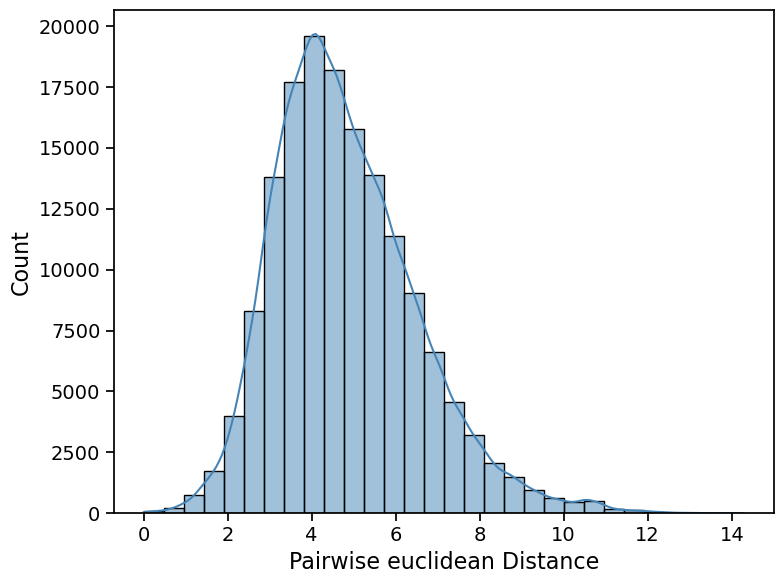

In [22]:
feature_space_distance_distribution(count_scaled_vector,'euclidean')

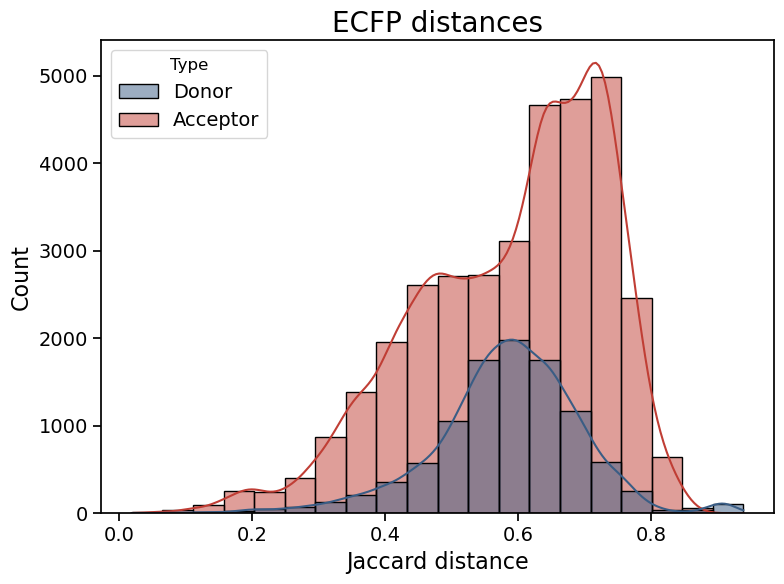

In [23]:
Donor_array  = np.array(Donor_molecule['Donor_ECFP6_count_512bits'].tolist())
Acceptor_array  = np.array(Acceptor_molecule['Acceptor_ECFP6_count_512bits'].tolist())

# Compute pairwise distances
Donor_tanimoto_similarities = pdist(Donor_array, metric=weighted_jaccard)
Acceptor_tanimoto_similarities  = pdist(Acceptor_array, metric=weighted_jaccard)

# Build dataframe
data = pd.DataFrame({
    "Similarity": np.concatenate([Donor_tanimoto_similarities, Acceptor_tanimoto_similarities]),
    "Type": (["Donor"] * len(Donor_tanimoto_similarities)) +
            (["Acceptor"] * len(Acceptor_tanimoto_similarities))
})

palette = {"Donor": "#3A5D85", "Acceptor": "#C03E35"}

# Plot
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x="Similarity", hue="Type", kde=True, bins=20, palette=palette)
plt.title("ECFP distances")
plt.xlabel("Jaccard distance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Clustering experimental conditions

In [24]:
aggregated_count_clustering_results = save_all_clustering_scores(count_scaled_vector,eps_range=np.arange(0.01, 1, 0.04), metric="euclidean")

/tmp/ipykernel_4480/3299047613.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clustering_score = pd.concat([clustering_score, KM_score], ignore_index=True)


In [25]:
bset_scores = get_best_clustering_scores(aggregated_count_clustering_results)

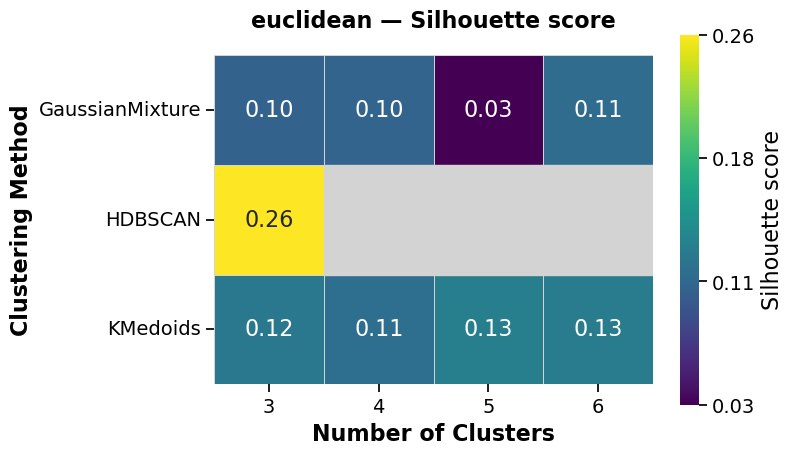

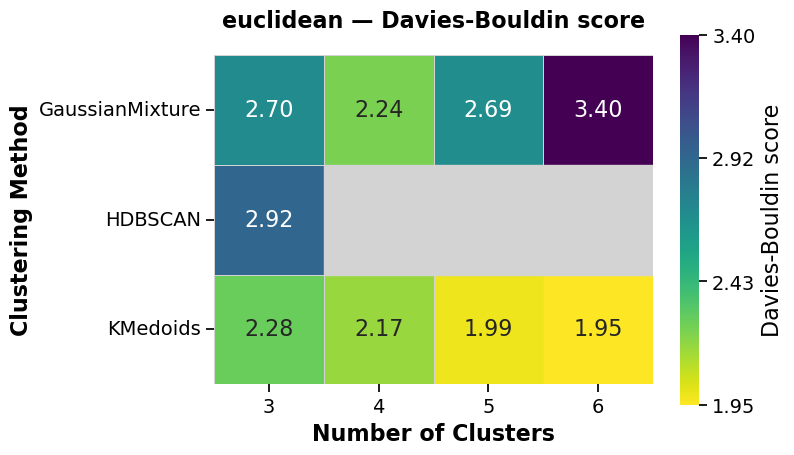

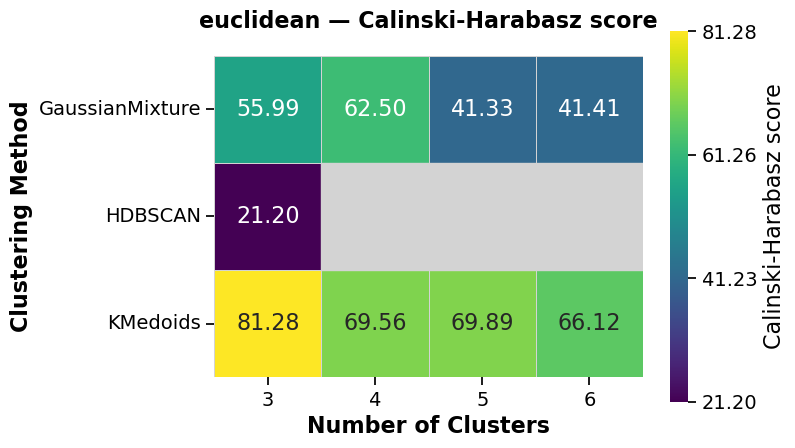

In [26]:
plot_clustering_score_heatmap(bset_scores)

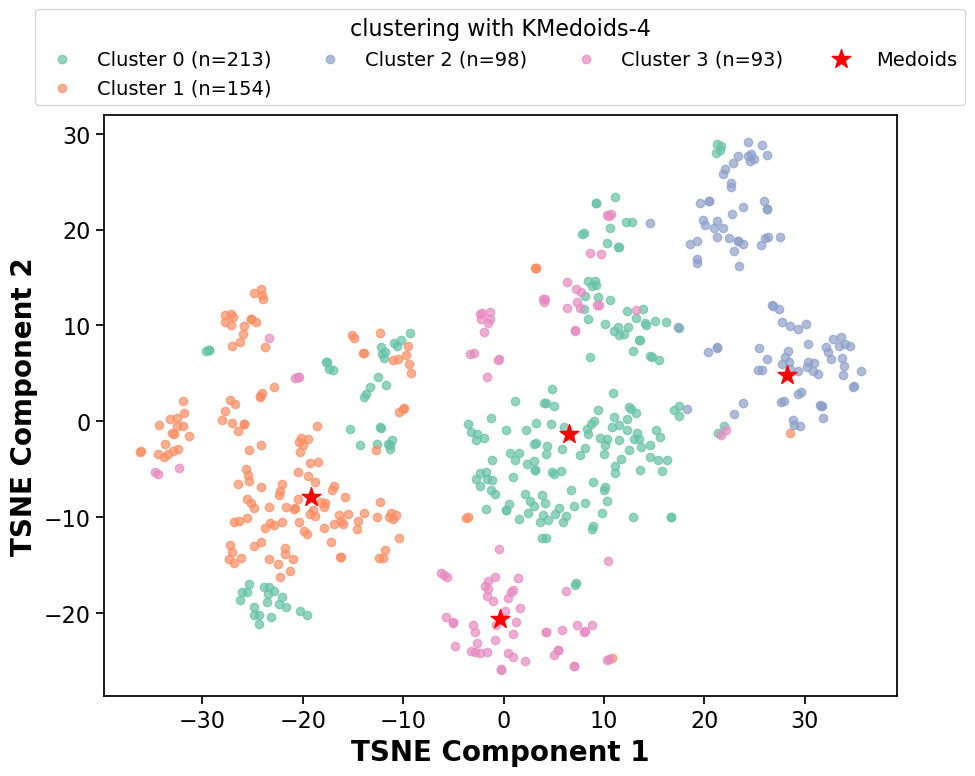

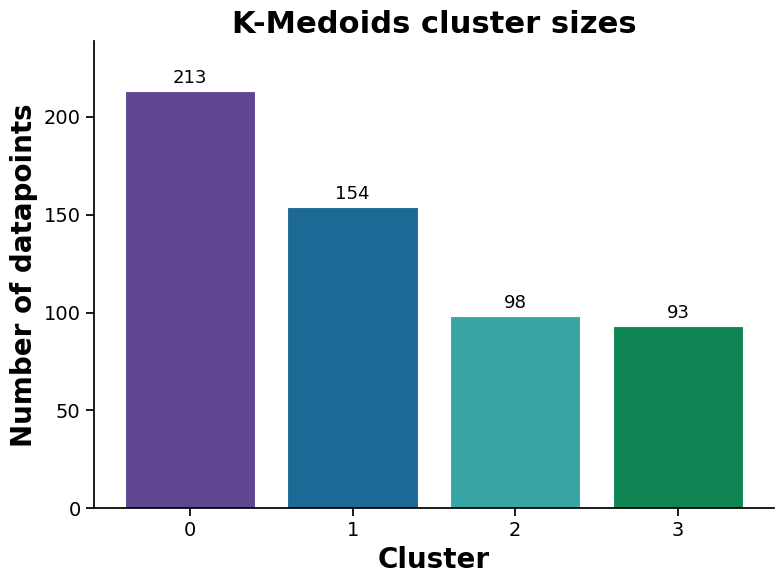

In [27]:
kmedoids_scores, kmedoids_labels, kmedoid_indices, kmedoids_tsne = get_clusters(
                  fp_vector=count_scaled_vector,
                  method='KMedoids',
                  n_clusters=4,
                  plotting=True,
                  get_label=True,
                  perplexity=30,
                  loc = 'upper center',
                  metric='euclidean'
                  )

kmedoids_cluster_sizes = plot_cluster_count(
    kmedoids_labels,
    title='K-Medoids cluster sizes',
)


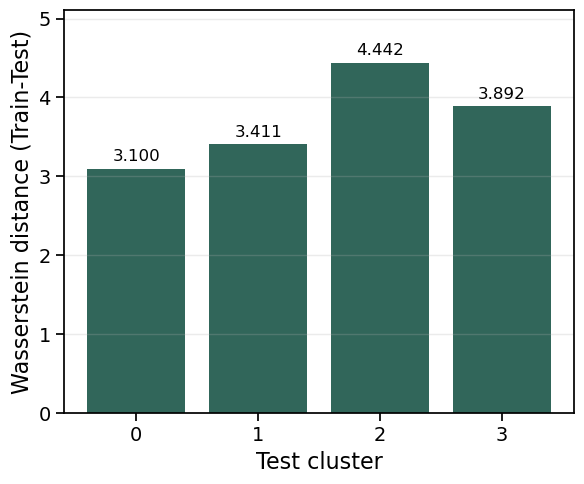

In [28]:
plot_cluster_wasserstein_distances(
    count_scaled_vector,
    kmedoids_labels,
    # title="",
    figsize=(6, 5)
)


### Clustering FPs

## Miniaturization of Popular Reactions from the Medicinal Chemists Toolbox for Ultrahigh-Throughput Experimentation

Specification

* ~768 datapoints

https://doi.org/10.1038/s44160-023-00351-1

https://github.com/cernaklab/medchem-reaction-miniaturization/blob/main/suzuki-ez.xlsx

In [80]:
Paper_name = "Miniaturization of Popular Reactions from the Medicinal Chemists Toolbox for Ultrahigh_Throughput Experimentation"
Dataset_name = "cleaned_suzuki_synthesis.pkl"
Conversion_data = pd.read_pickle(DATASETS / Paper_name / Dataset_name)

### Initial Analysis

In [87]:
std_caler = StandardScaler()
FP_unit = f"{DATASET_CONFIG[Paper_name]['polymer_unit'][0]} SMILES"
count_space = Conversion_data[DATASET_CONFIG[Paper_name]["features"]].to_numpy(dtype=float)
count_scaled_vector = std_caler.fit_transform(count_space)
molecules = Conversion_data.drop_duplicates(subset=FP_unit).reset_index(drop=True)
print(len(molecules))

16


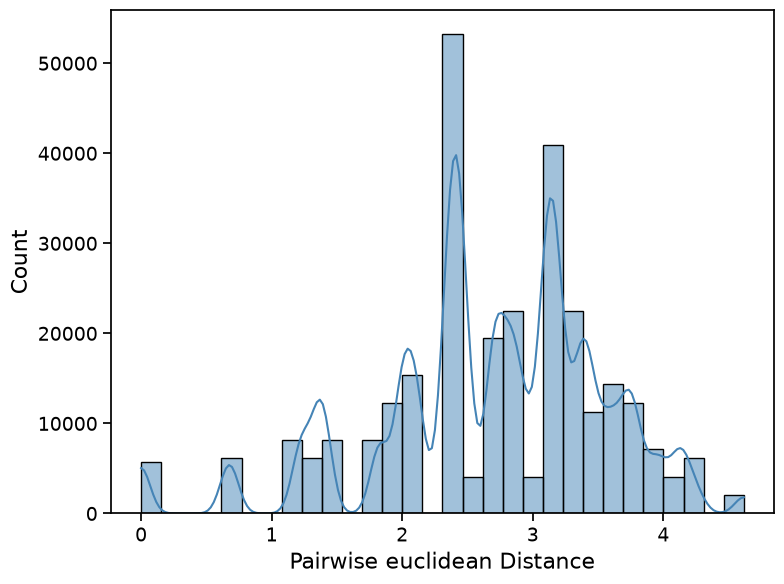

In [88]:
feature_space_distance_distribution(count_scaled_vector,'euclidean')

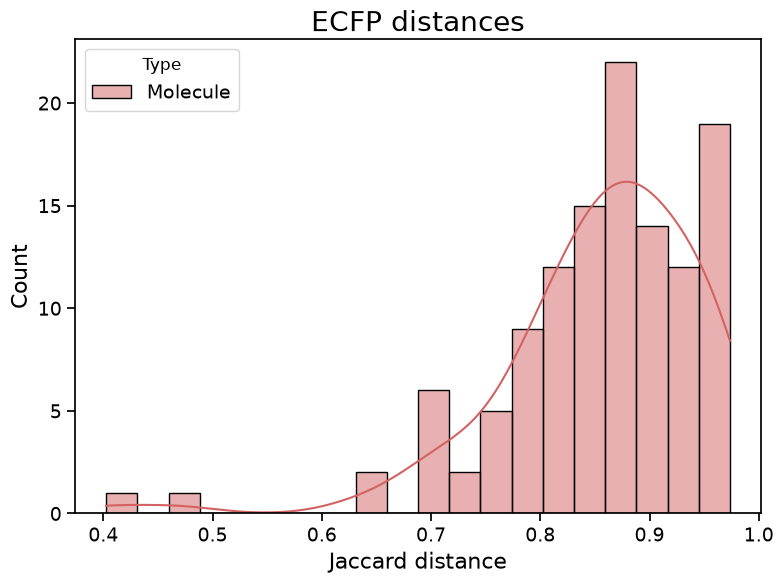

In [89]:
molecules_array  = np.array(molecules['Substrate_ECFP6_count_512bits'].tolist())

# Compute pairwise distances
molecules_tanimoto_similarities  = pdist(molecules_array, metric=weighted_jaccard)

# Build dataframe
data = pd.DataFrame({
    "Similarity": np.concatenate([molecules_tanimoto_similarities]),
    "Type": (["Molecule"] * len(molecules_tanimoto_similarities))
})

palette = {"Molecule": "#D36262"}

# Plot
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x="Similarity", hue="Type", kde=True, bins=20, palette=palette)
plt.title("ECFP distances")
plt.xlabel("Jaccard distance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Clustering experimental conditions

In [95]:
aggregated_count_clustering_results = save_all_clustering_scores(count_scaled_vector,eps_range=np.arange(0.01, 1, 0.04), metric="euclidean")

/tmp/ipykernel_1318956/2613718201.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clustering_score = pd.concat([clustering_score, KM_score], ignore_index=True)


In [96]:
bset_scores = get_best_clustering_scores(aggregated_count_clustering_results)

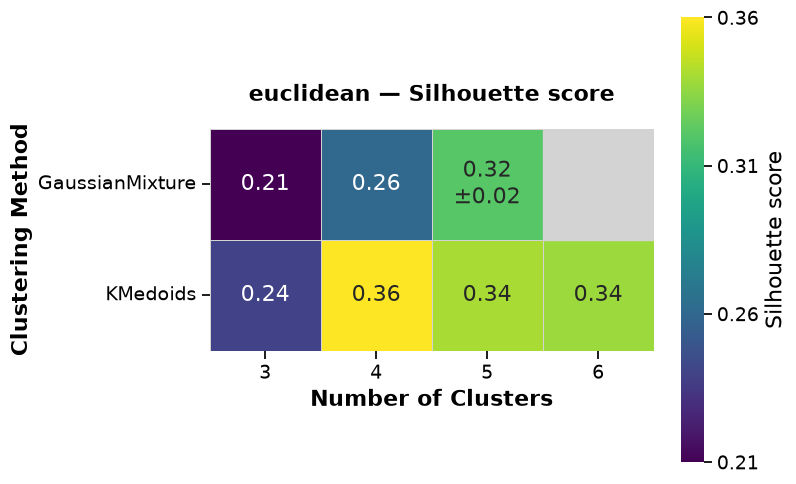

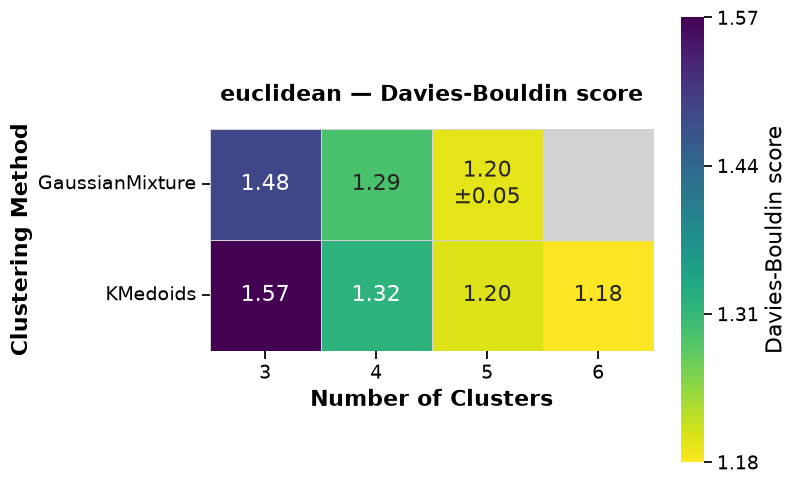

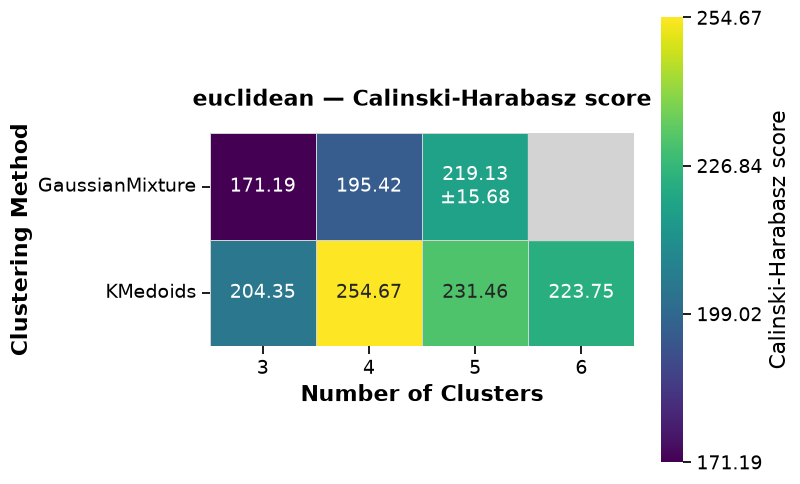

In [97]:
plot_clustering_score_heatmap(bset_scores)

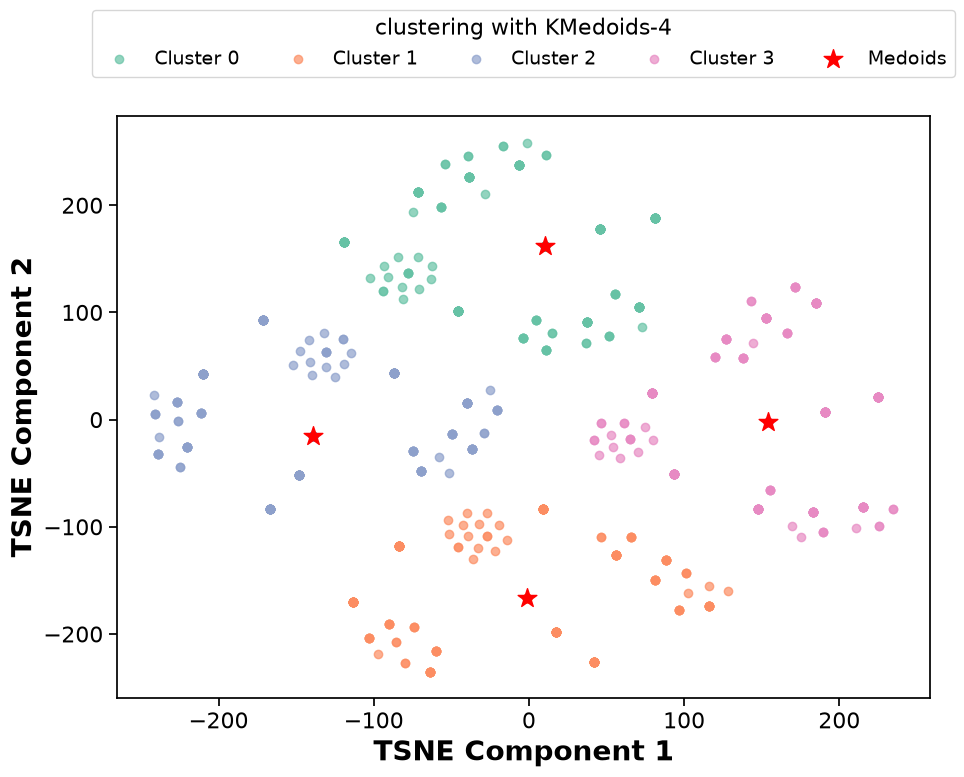

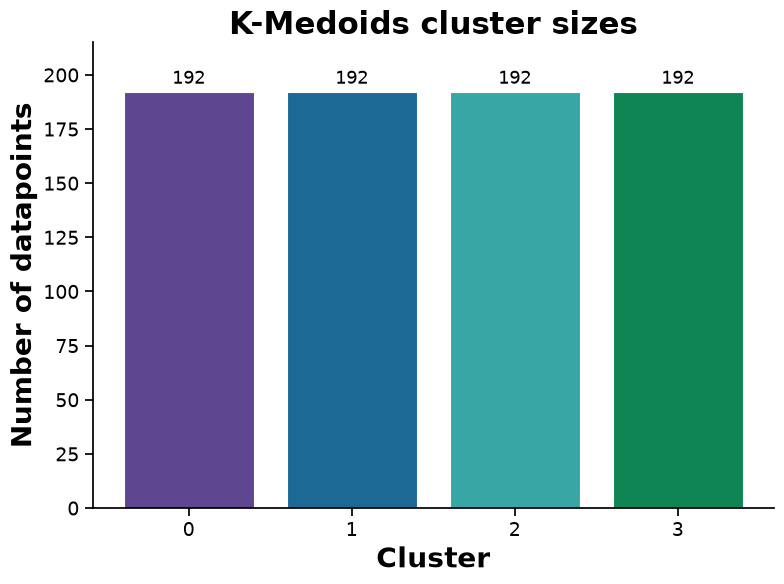

In [100]:
kmedoids_scores, kmedoids_labels, kmedoid_indices, kmedoids_tsne = get_clusters(
                  fp_vector=count_scaled_vector,
                  method='KMedoids',
                  n_clusters=4,
                  plotting=True,
                  get_label=True,
                  perplexity=40,
                  loc = 'upper center',
                  metric='euclidean'
                  )

kmedoids_cluster_sizes = plot_cluster_count(
    kmedoids_labels,
    title='K-Medoids cluster sizes',
)


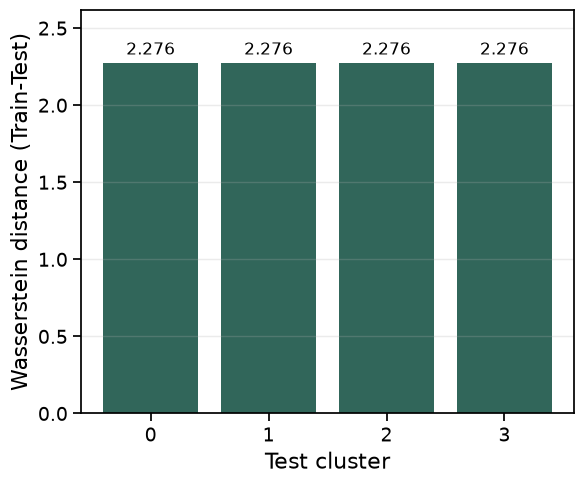

In [101]:
plot_cluster_wasserstein_distances(
    count_scaled_vector,
    kmedoids_labels,
    # title="",
    figsize=(6, 5)
)


### Clustering FPs

## *Machine Learning for Polymer Design to Enhance Pervaporation-Based Organic Recovery*

**Specification**


*   52 unique polymers and 32 types of organic solutes
*   2341 datapoints

**Targets**
* total flux J (kg m–2 h–1)
* separation factor βB/A.



https://doi.org/10.1021/acs.est.4c00060

In [56]:
Paper_name = "Machine Learning for Polymer Design to Enhance Pervaporation-Based Organic Recovery"
flux_data_name = "flux_data_imputed"
separation_data_name = "separation_data_imputed"
FLUX_data = pd.read_pickle(DATASETS / Paper_name / f"{flux_data_name}.pkl")
SEPARATION_data = pd.read_pickle(DATASETS / Paper_name / f"{separation_data_name}.pkl")

### Initial Analysis

In [57]:
std_caler = StandardScaler()
FP_unit = f"{DATASET_CONFIG[Paper_name]['polymer_unit'][0]} SMILES"
FLUX_count_space = FLUX_data[DATASET_CONFIG[Paper_name]["features"]].to_numpy(dtype=float)
FLUX_count_scaled_vector = std_caler.fit_transform(FLUX_count_space)
FLUX_molecules = FLUX_data.drop_duplicates(subset=FP_unit).reset_index(drop=True)
print(len(FLUX_molecules))

SEPARATION_count_space = SEPARATION_data[DATASET_CONFIG[Paper_name]["features"]].to_numpy(dtype=float)
SEPARATION_count_scaled_vector = std_caler.transform(SEPARATION_count_space)
SEPARATION_molecules = SEPARATION_data.drop_duplicates(subset=FP_unit).reset_index(drop=True)
print(len(SEPARATION_molecules))

53
53


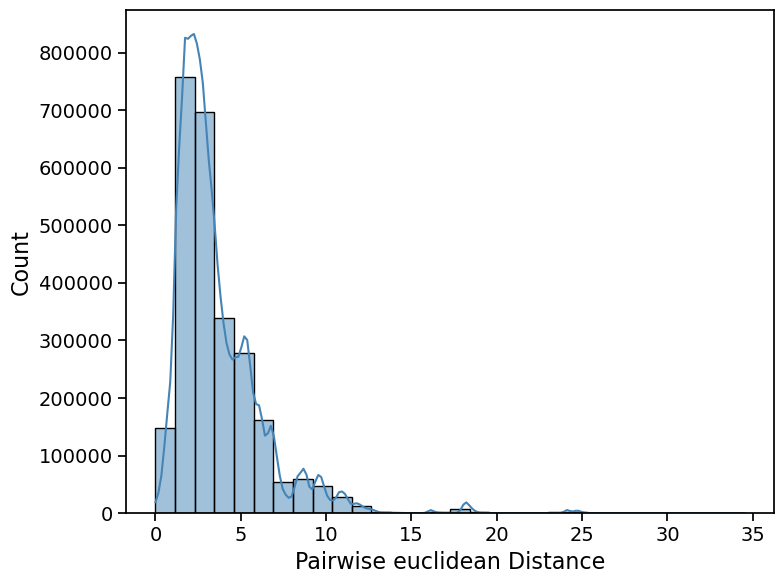

In [58]:
feature_space_distance_distribution(FLUX_count_scaled_vector,'euclidean')

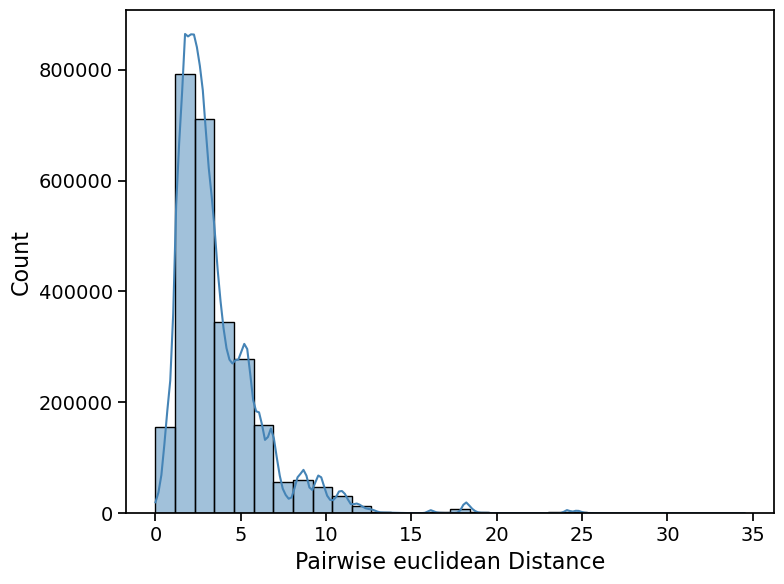

In [59]:
feature_space_distance_distribution(SEPARATION_count_scaled_vector,'euclidean')

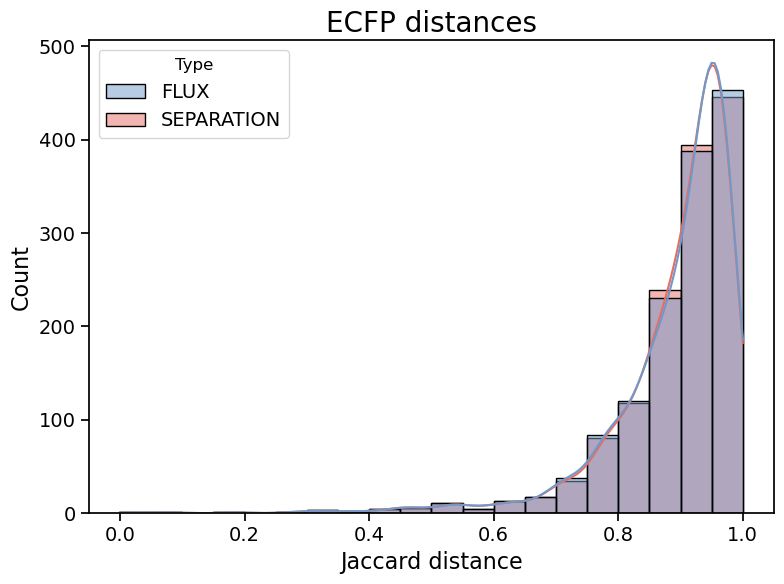

In [60]:
FLUX_molecules_array = np.array(
    FLUX_molecules[
        f"{DATASET_CONFIG[Paper_name]['polymer_unit'][0]}_ECFP6_count_512bits"
    ].tolist()
)

SEPARATION_molecules_array = np.array(
    SEPARATION_molecules[
        f"{DATASET_CONFIG[Paper_name]['polymer_unit'][0]}_ECFP6_count_512bits"
    ].tolist()
)

FLUX_distances = pdist(
    FLUX_molecules_array,
    metric=weighted_jaccard,
)

SEPARATION_distances = pdist(
    SEPARATION_molecules_array,
    metric=weighted_jaccard,
)

# Build dataframe
data = pd.DataFrame({
    "Distance": np.concatenate([
        FLUX_distances,
        SEPARATION_distances,
    ]),
    "Type": (
        ["FLUX"] * len(FLUX_distances)
        + ["SEPARATION"] * len(SEPARATION_distances)
    ),
})

palette = {
           "FLUX": "#7099C9",
           "SEPARATION": "#E76D64"}

# Plot
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x="Distance", hue="Type", kde=True, bins=20, palette=palette)
plt.title("ECFP distances")
plt.xlabel("Jaccard distance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Clustering experimental conditions

In [61]:
FLUX_aggregated_count_clustering_results = save_all_clustering_scores(FLUX_count_scaled_vector,eps_range=np.arange(0.01, 1, 0.04), n_clusters=range(2, 10), metric="euclidean")

/tmp/ipykernel_4480/3299047613.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clustering_score = pd.concat([clustering_score, KM_score], ignore_index=True)


In [62]:
SEPARATION_aggregated_count_clustering_results = save_all_clustering_scores(SEPARATION_count_scaled_vector,eps_range=np.arange(0.01, 1, 0.04), n_clusters=range(2, 10), metric="euclidean")

/tmp/ipykernel_4480/3299047613.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clustering_score = pd.concat([clustering_score, KM_score], ignore_index=True)


In [63]:
best_FLUX_scores = get_best_clustering_scores(FLUX_aggregated_count_clustering_results)
best_SEPARATION_scores = get_best_clustering_scores(SEPARATION_aggregated_count_clustering_results)


Best FLUX clustering scores:


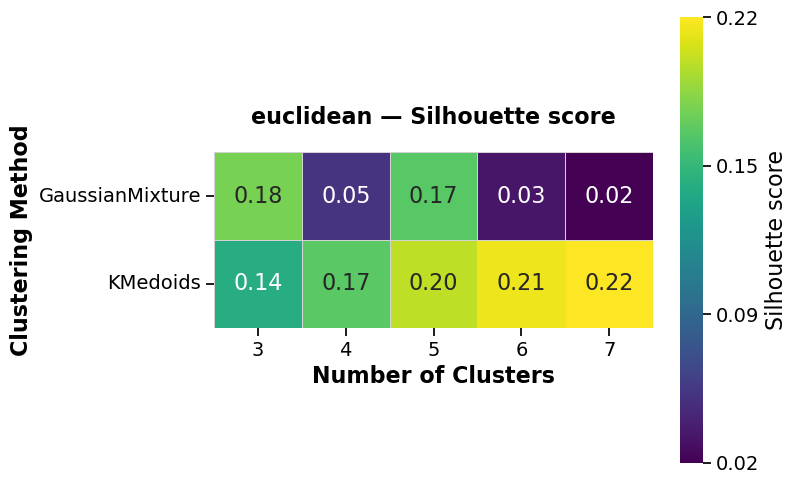

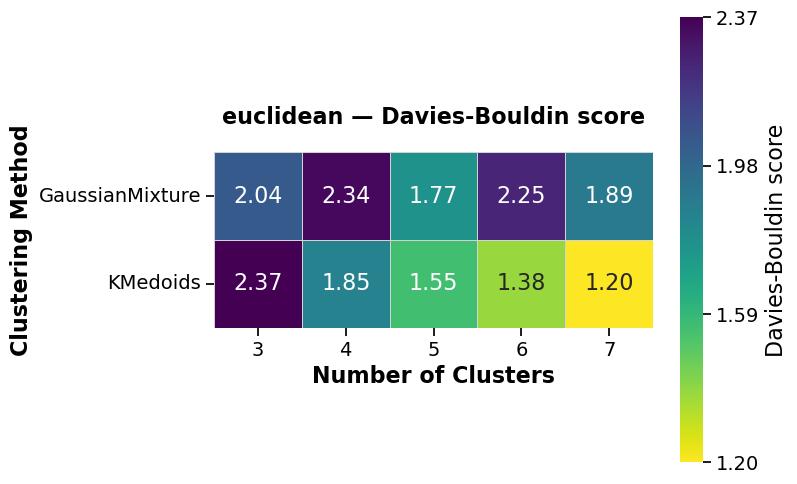

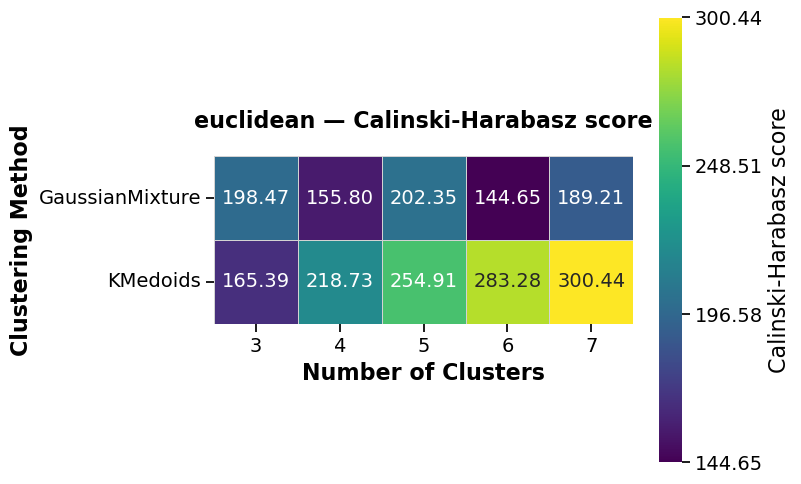

In [64]:
print("Best FLUX clustering scores:")
plot_clustering_score_heatmap(best_FLUX_scores)

Best SEPARATION clustering scores:


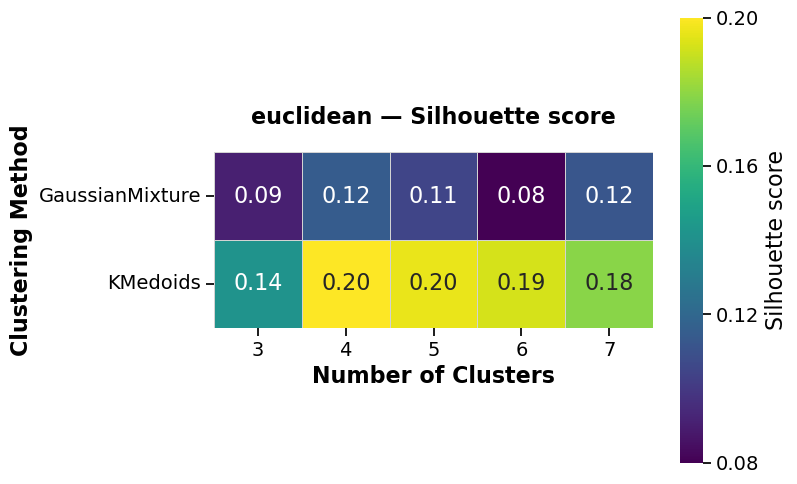

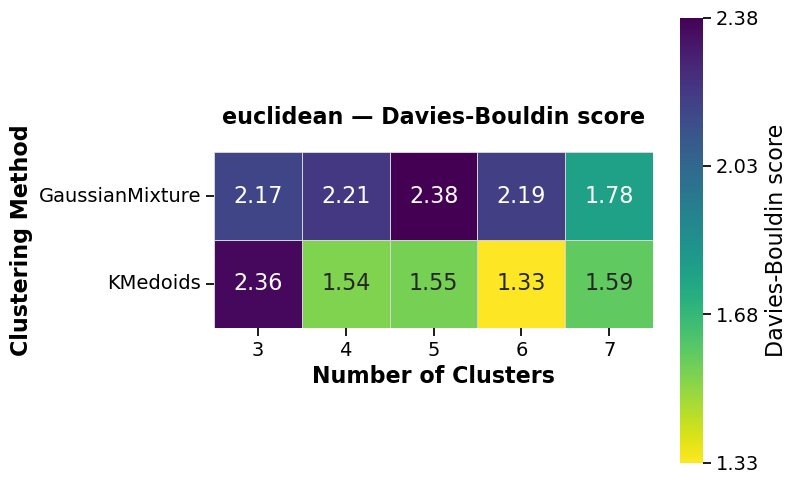

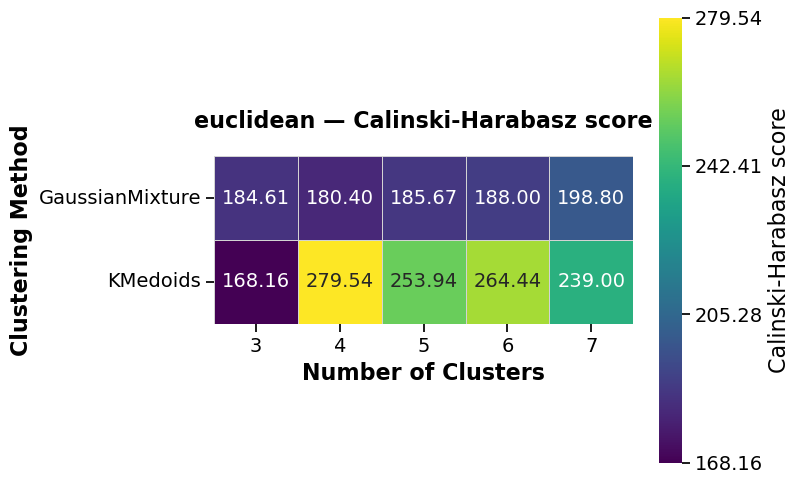

In [65]:
print("Best SEPARATION clustering scores:")
plot_clustering_score_heatmap(best_SEPARATION_scores)

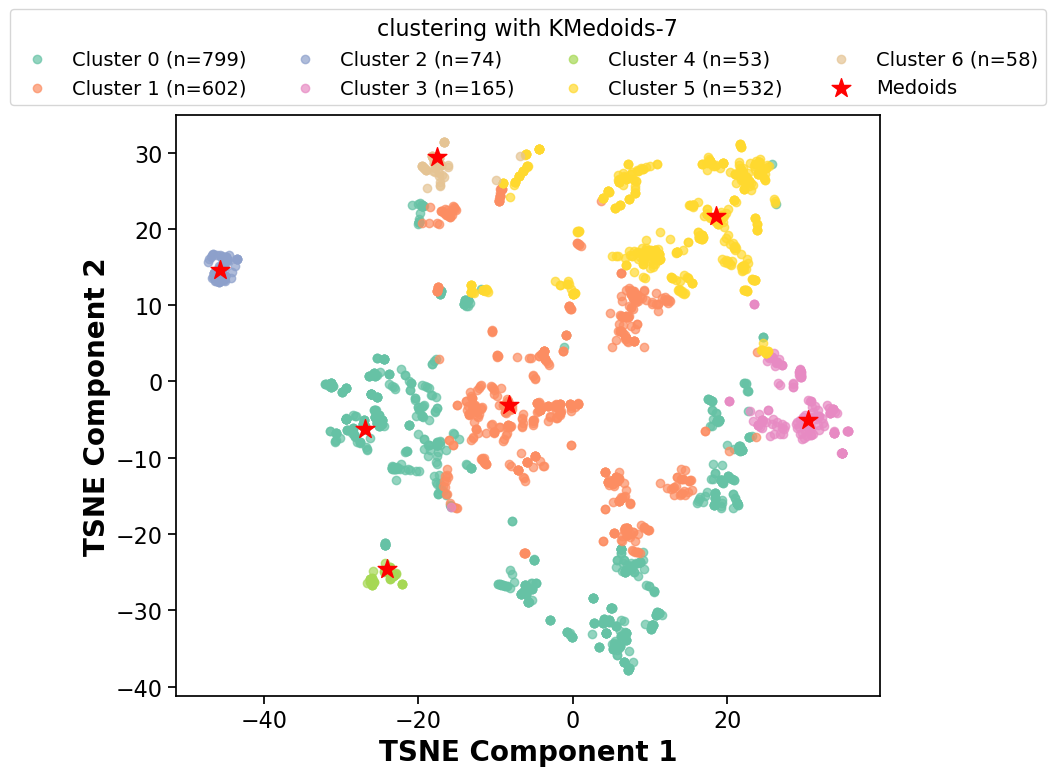

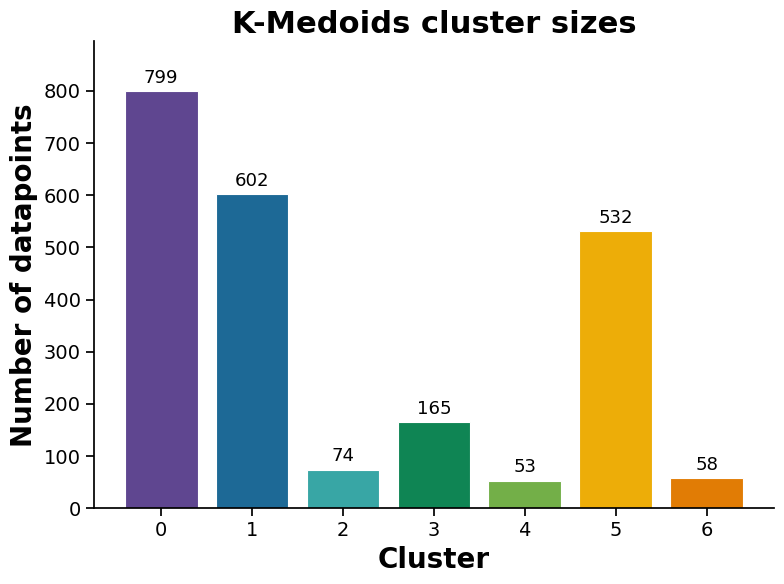

In [66]:
kmedoids_scores, kmedoids_labels, kmedoid_indices, kmedoids_tsne = get_clusters(
                  fp_vector=FLUX_count_scaled_vector,
                  method='KMedoids',
                  n_clusters=7,
                  plotting=True,
                  get_label=True,
                  perplexity=70,
                  loc = 'upper center',
                  metric='euclidean'
                  )

kmedoids_cluster_sizes = plot_cluster_count(
    kmedoids_labels,
    title='K-Medoids cluster sizes',
)


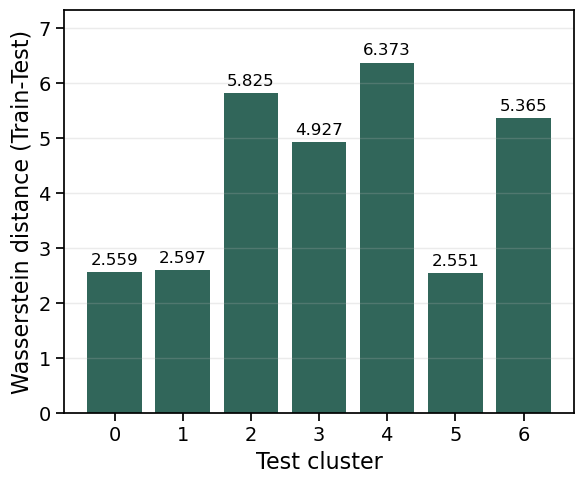

In [67]:
plot_cluster_wasserstein_distances(
    FLUX_count_scaled_vector,
    kmedoids_labels,
    # title="",
    figsize=(6, 5)
)


In [68]:
FLUX_count_scaled_vector.ndim

2

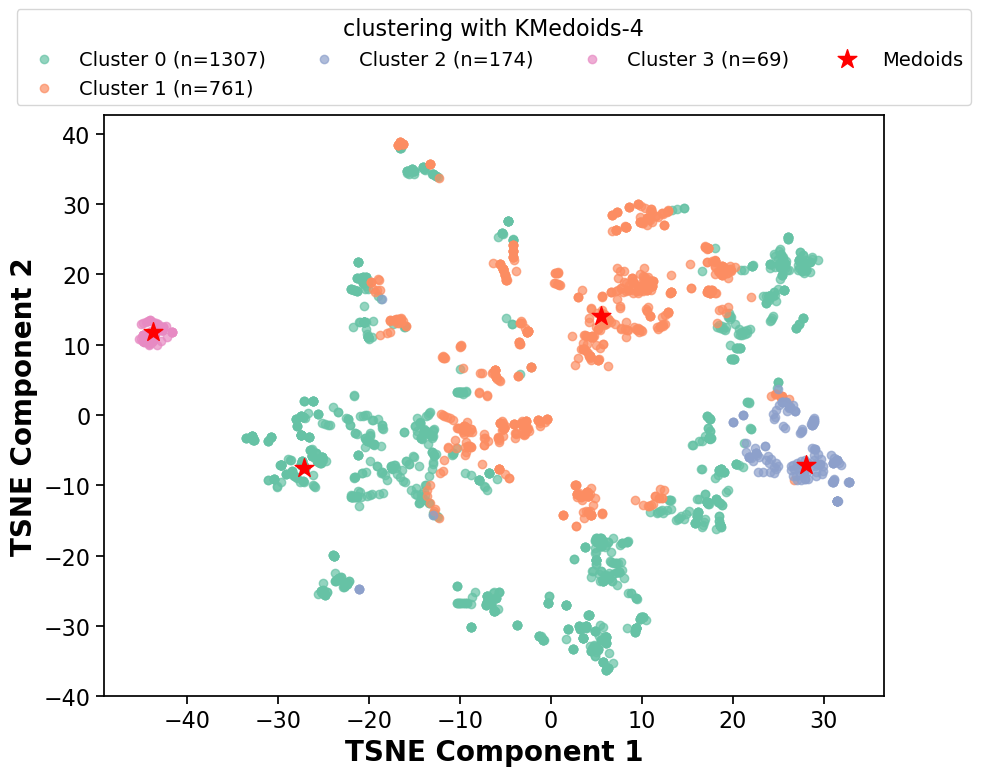

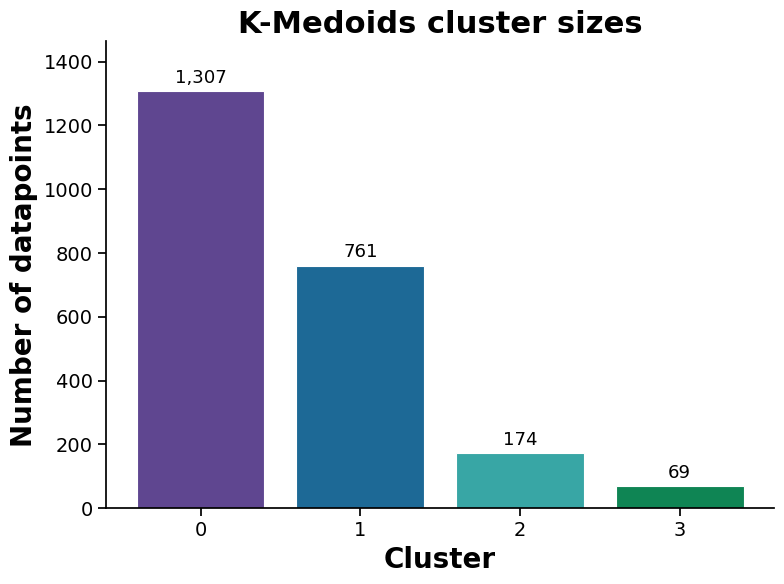

In [72]:
kmedoids_scores, kmedoids_labels, kmedoid_indices, kmedoids_tsne = get_clusters(
                  fp_vector=SEPARATION_count_scaled_vector,
                  method='KMedoids',
                  n_clusters=4,
                  plotting=True,
                  get_label=True,
                  perplexity=70,
                  loc = 'upper center',
                  metric='euclidean'
                  )

kmedoids_cluster_sizes = plot_cluster_count(
    kmedoids_labels,
    title='K-Medoids cluster sizes',
)


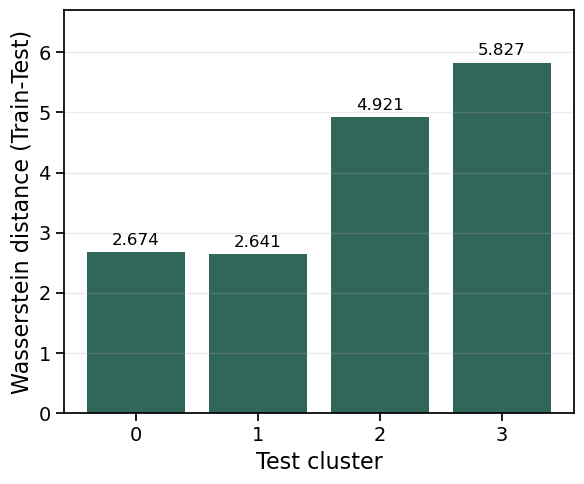

In [73]:
plot_cluster_wasserstein_distances(
    SEPARATION_count_scaled_vector,
    kmedoids_labels,
    # title="",
    figsize=(6, 5)
)


### Clustering FPs

## Machine Learning-Enabled Prediction and High-Throughput Screening of Polymer Membranes for Pervaporation Separation

Specification


*   681 datapoints
*   16 unique polymers




https://doi.org/10.1021/acsami.1c22886

In [74]:
Paper_name = "Machine Learning-Enabled Prediction and High-Throughput Screening of Polymer Membranes for Pervaporation Separation"
Dataset_name = "cleaned_dataset_pervaporation_membranes_wang.pkl"
pervaporation_data = pd.read_pickle(DATASETS / Paper_name / Dataset_name)

### Initial Analysis

In [81]:
std_caler = StandardScaler()
count_space = pervaporation_data[DATASET_CONFIG[Paper_name]["features"]].to_numpy(dtype=float)
count_scaled_vector = std_caler.fit_transform(count_space)

FP_unit = f"{DATASET_CONFIG[Paper_name]['polymer_unit'][0]} SMILES"
molecules = pervaporation_data.drop_duplicates(subset=FP_unit).reset_index(drop=True)
print(len(molecules))


16


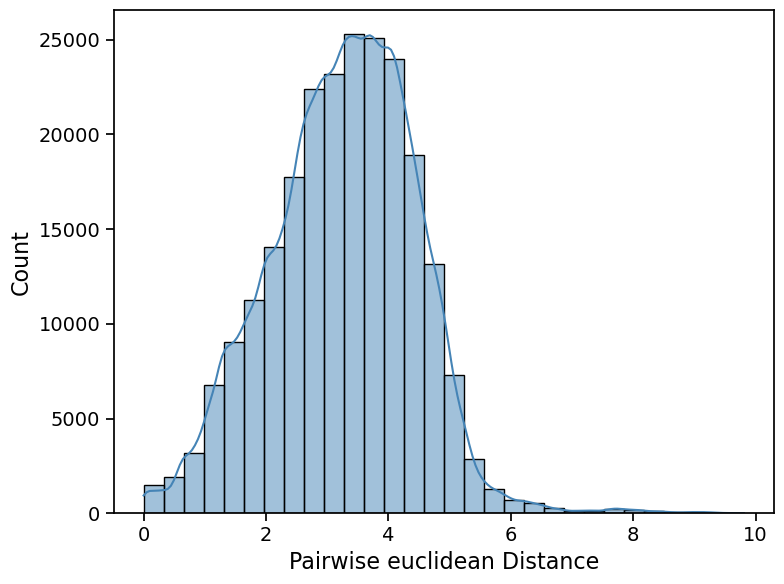

In [109]:
feature_space_distance_distribution(count_scaled_vector,'euclidean')

In [79]:
DATASET_CONFIG[Paper_name]['polymer_unit'][0]

'polymer'

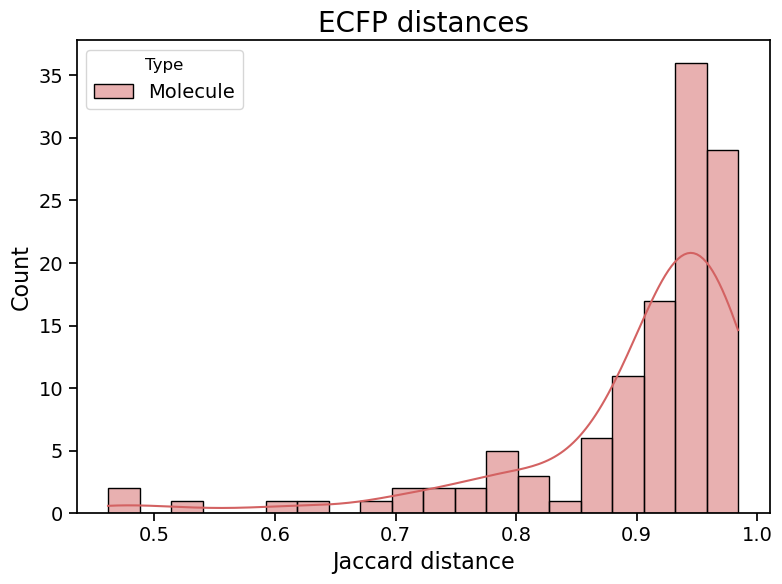

In [83]:
molecules_array  = np.array(molecules[f"{DATASET_CONFIG[Paper_name]['polymer_unit'][0]}_ECFP6_count_512bits"].tolist())

# Compute pairwise distances
molecules_tanimoto_similarities  = pdist(molecules_array, metric=weighted_jaccard)

# Build dataframe
data = pd.DataFrame({
    "Similarity": np.concatenate([molecules_tanimoto_similarities]),
    "Type": (["Molecule"] * len(molecules_tanimoto_similarities))
})

palette = {"Molecule": "#D36262"}

# Plot
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x="Similarity", hue="Type", kde=True, bins=20, palette=palette)
plt.title("ECFP distances")
plt.xlabel("Jaccard distance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Clustering experimental conditions

In [96]:
aggregated_count_clustering_results = save_all_clustering_scores(count_scaled_vector,eps_range=np.arange(0.01, 1, 0.04), metric="euclidean", n_clusters=range(2, 11))

/tmp/ipykernel_4480/3299047613.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clustering_score = pd.concat([clustering_score, KM_score], ignore_index=True)


In [99]:
best_scores = get_best_clustering_scores(aggregated_count_clustering_results, 
                                         range_n_clusters=(2, 11))

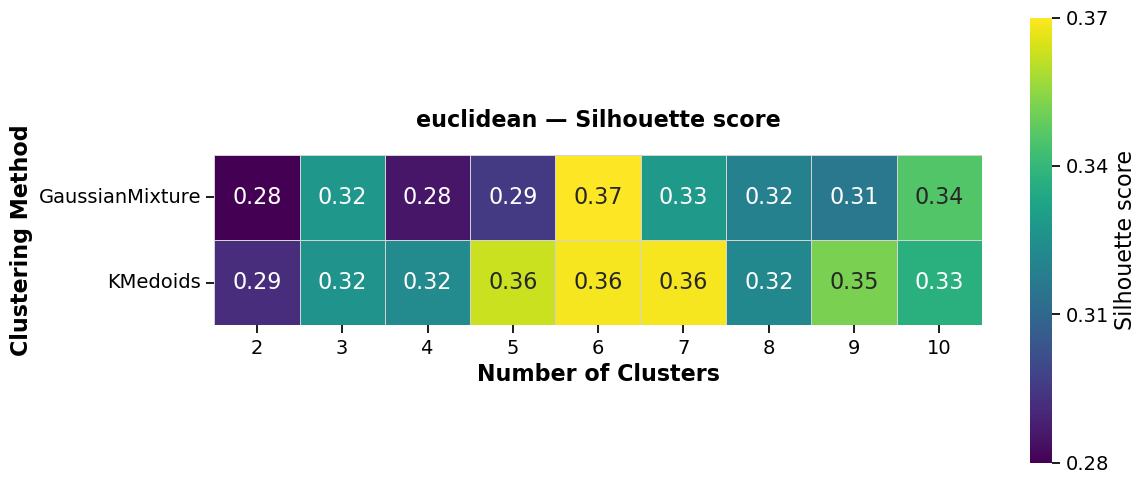

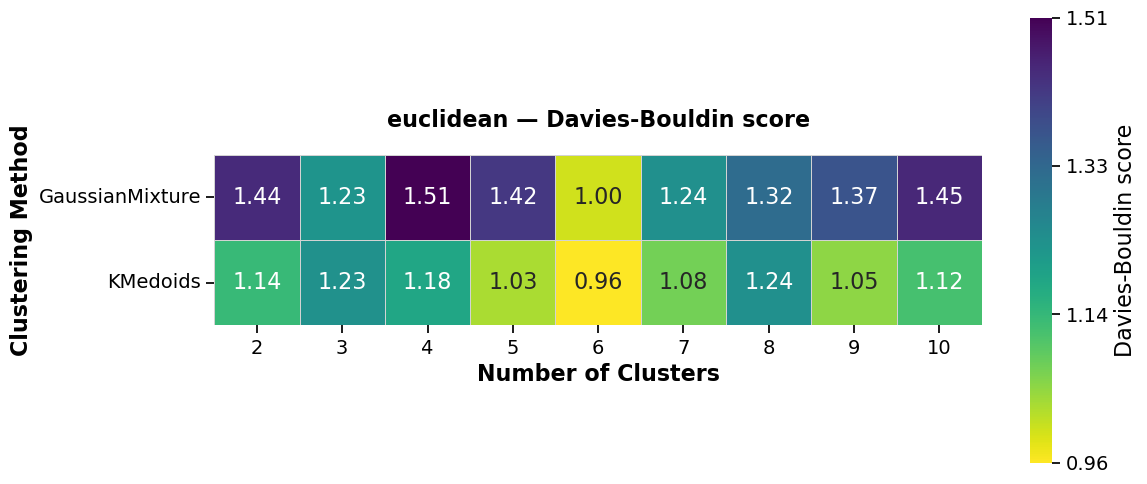

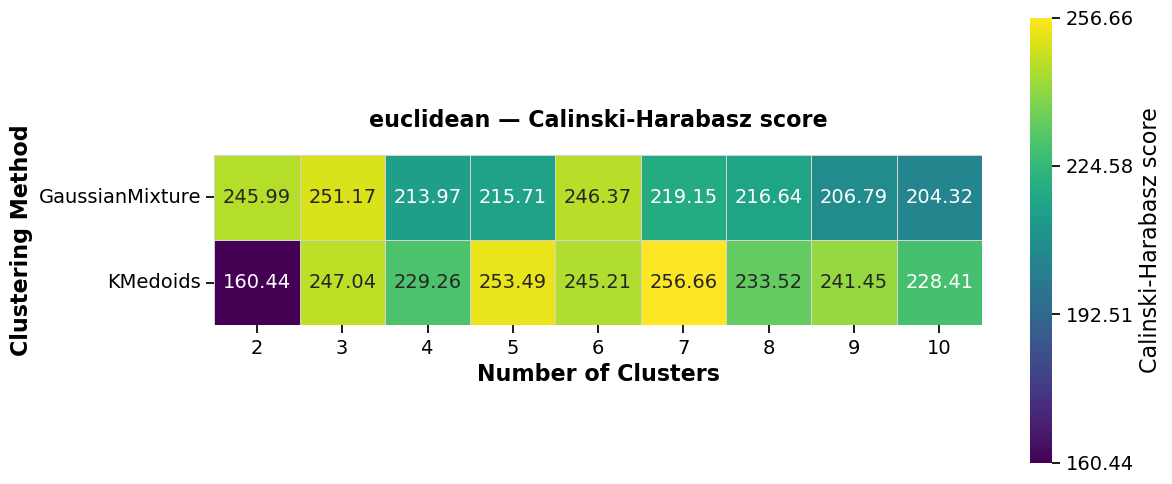

In [103]:
plot_clustering_score_heatmap(best_scores, figsize=(12, 5))

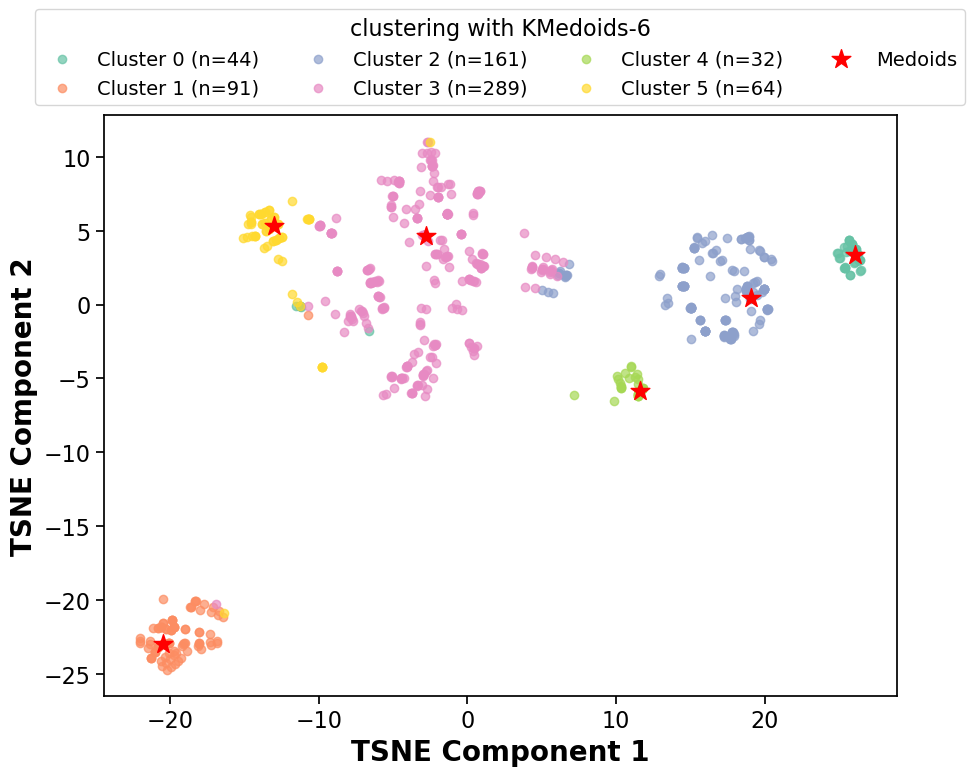

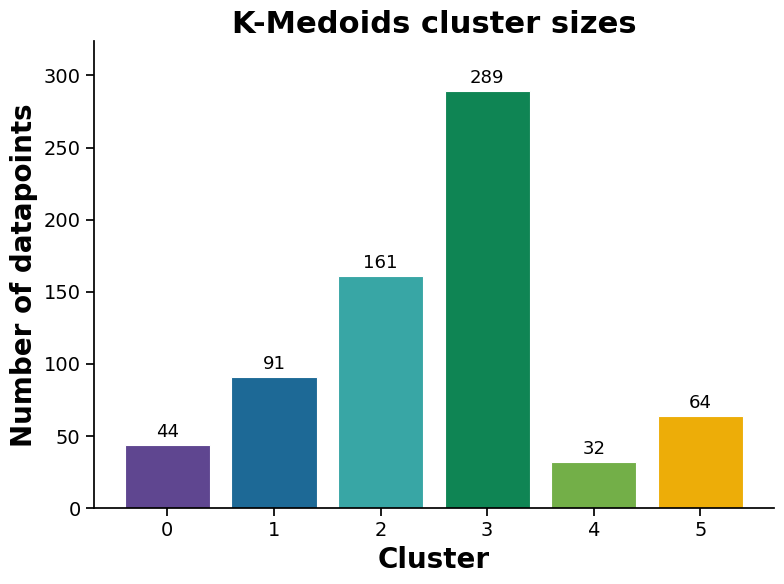

In [105]:
kmedoids_scores, kmedoids_labels, kmedoid_indices, kmedoids_tsne = get_clusters(
                  fp_vector=count_scaled_vector,
                  method='KMedoids',
                  n_clusters=6,
                  plotting=True,
                  get_label=True,
                  perplexity=70,
                  loc = 'upper center',
                  metric='euclidean'
                  )

kmedoids_cluster_sizes = plot_cluster_count(
    kmedoids_labels,
    title='K-Medoids cluster sizes',
)


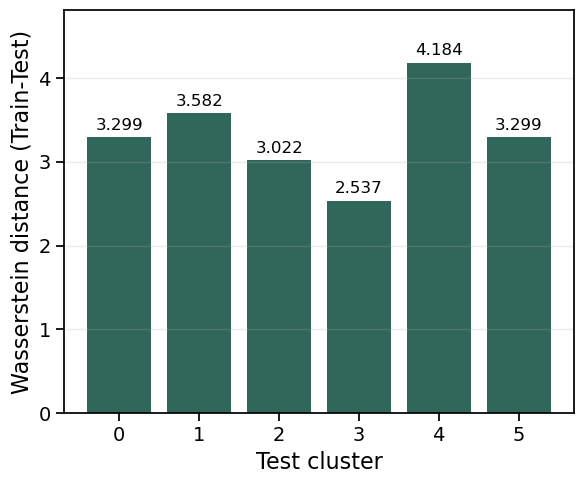

In [106]:
plot_cluster_wasserstein_distances(
    count_scaled_vector,
    kmedoids_labels,
    # title="",
    figsize=(6, 5)
)


### Clustering FPs

## Understanding and Designing a High-Performance Ultrafiltration Membrane Using Machine Learning

specification


*   320 datapoints
*   11 unique polymers



https://doi.org/10.1021/acs.est.2c05404

In [110]:
Paper_name = "Understanding and Designing a High-Performance Ultrafiltration Membrane Using Machine Learning"
Dataset_name = "cleaned_dataset_Ultrafiltration Membrane_imputed.pkl"
Ultrafiltration_data = pd.read_pickle(DATASETS / Paper_name / Dataset_name)

### Initial Analysis

In [111]:
std_caler = StandardScaler()
count_space = Ultrafiltration_data[DATASET_CONFIG[Paper_name]["features"]].to_numpy(dtype=float)
count_scaled_vector = std_caler.fit_transform(count_space)

FP_unit = f"{DATASET_CONFIG[Paper_name]['polymer_unit'][0]} SMILES"
molecules = Ultrafiltration_data.drop_duplicates(subset=FP_unit).reset_index(drop=True)
print(len(molecules))


11


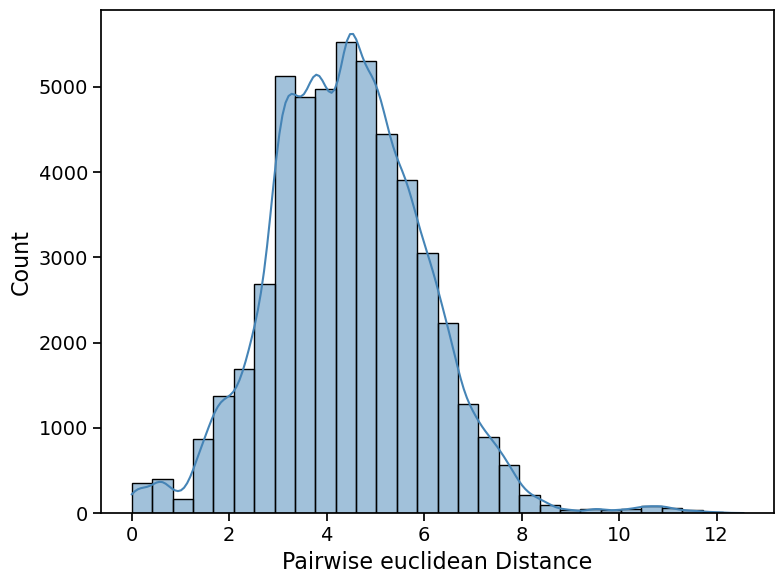

In [112]:
feature_space_distance_distribution(count_scaled_vector,'euclidean')

In [113]:
DATASET_CONFIG[Paper_name]['polymer_unit'][0]

'polymer'

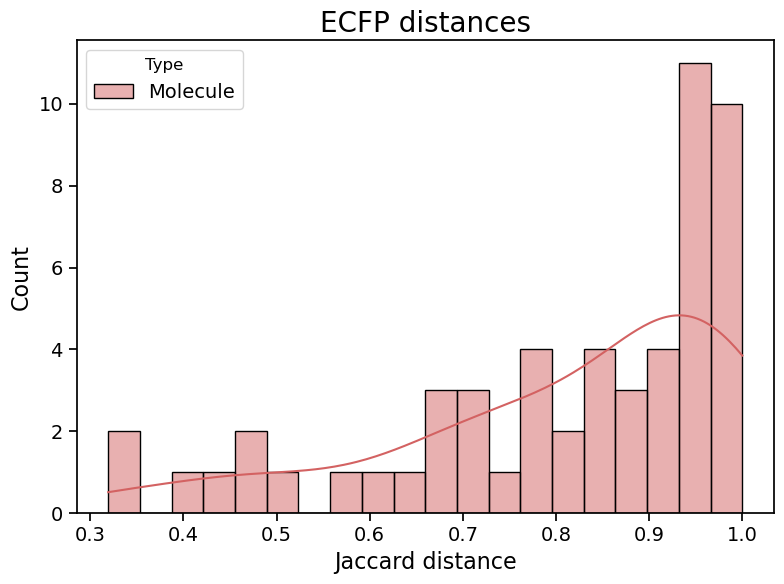

In [114]:
molecules_array  = np.array(molecules[f"{DATASET_CONFIG[Paper_name]['polymer_unit'][0]}_ECFP6_count_512bits"].tolist())

# Compute pairwise distances
molecules_tanimoto_similarities  = pdist(molecules_array, metric=weighted_jaccard)

# Build dataframe
data = pd.DataFrame({
    "Similarity": np.concatenate([molecules_tanimoto_similarities]),
    "Type": (["Molecule"] * len(molecules_tanimoto_similarities))
})

palette = {"Molecule": "#D36262"}

# Plot
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x="Similarity", hue="Type", kde=True, bins=20, palette=palette)
plt.title("ECFP distances")
plt.xlabel("Jaccard distance")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Clustering experimental conditions

In [127]:
aggregated_count_clustering_results = save_all_clustering_scores(count_scaled_vector,eps_range=np.arange(0.01, 1, 0.04), metric="euclidean", n_clusters=range(2, 21))

/tmp/ipykernel_4480/3299047613.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clustering_score = pd.concat([clustering_score, KM_score], ignore_index=True)


In [128]:
best_scores = get_best_clustering_scores(aggregated_count_clustering_results, 
                                         range_n_clusters=(2, 20))

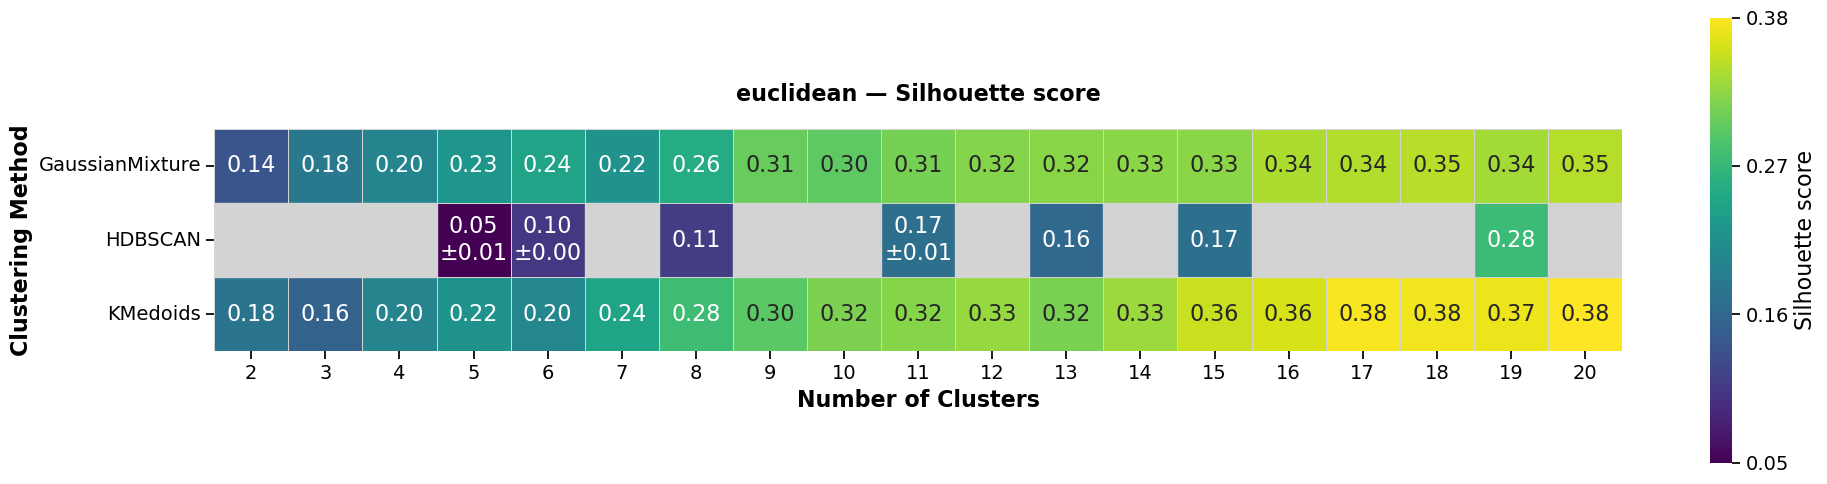

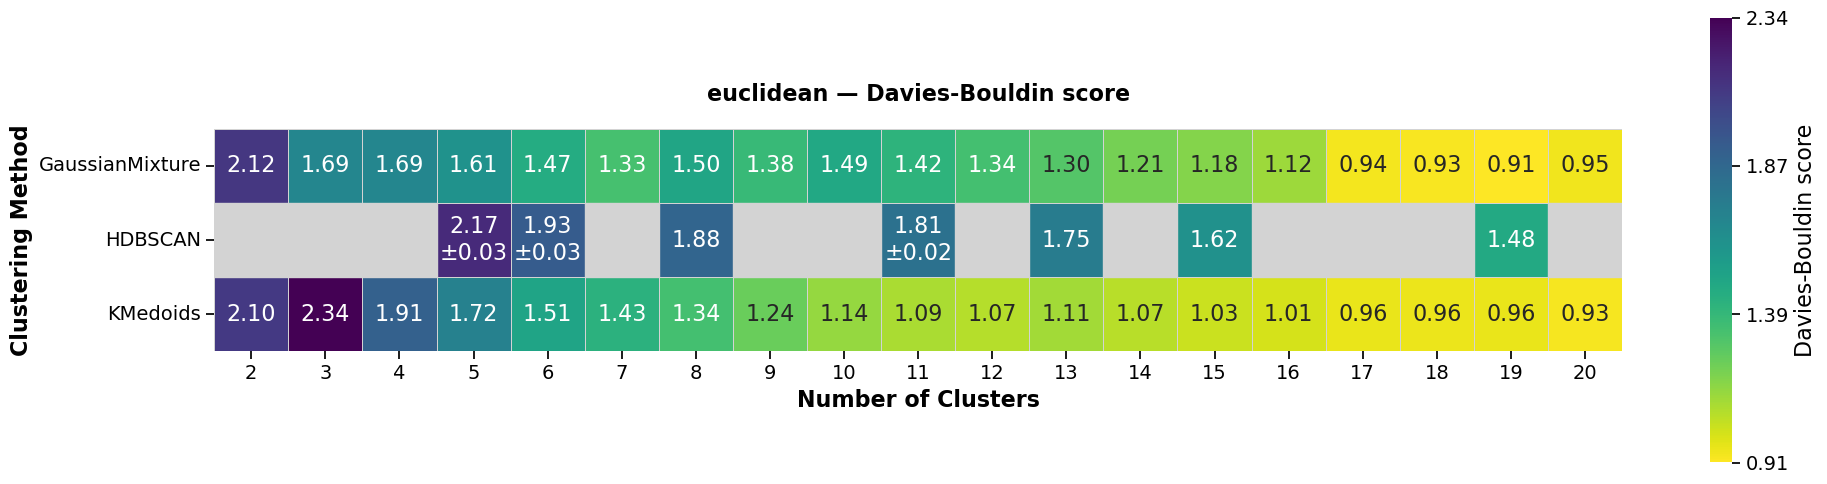

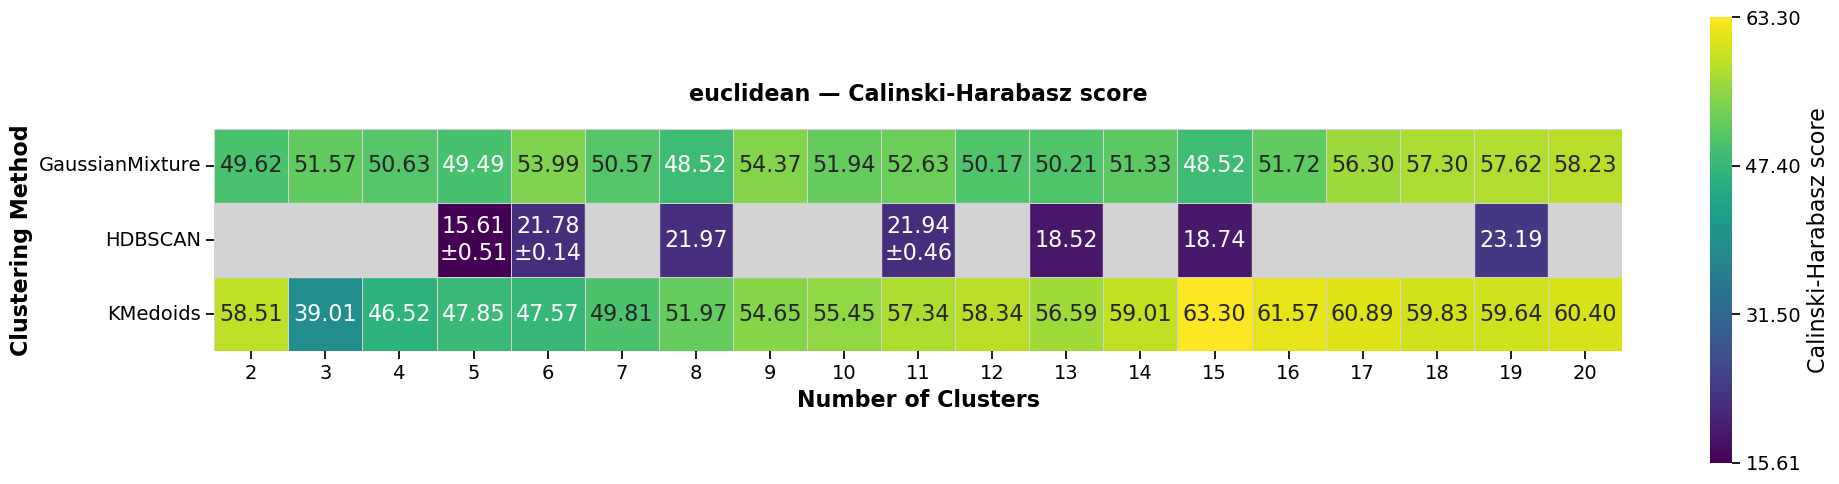

In [130]:
plot_clustering_score_heatmap(best_scores, figsize=(20, 5))

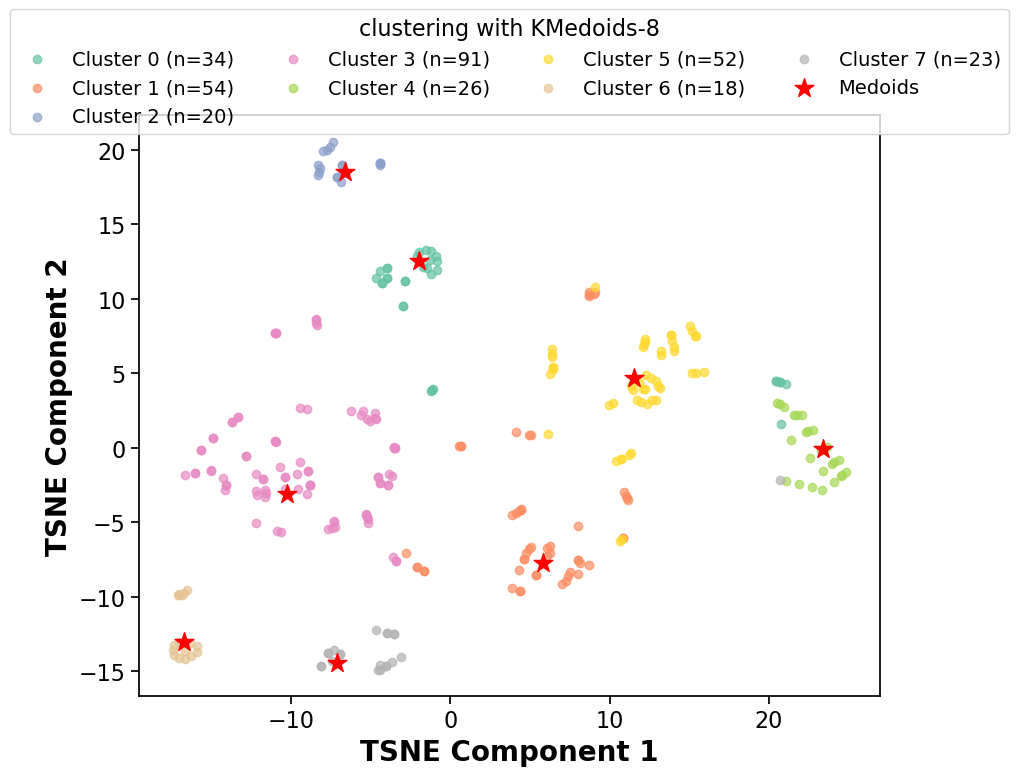

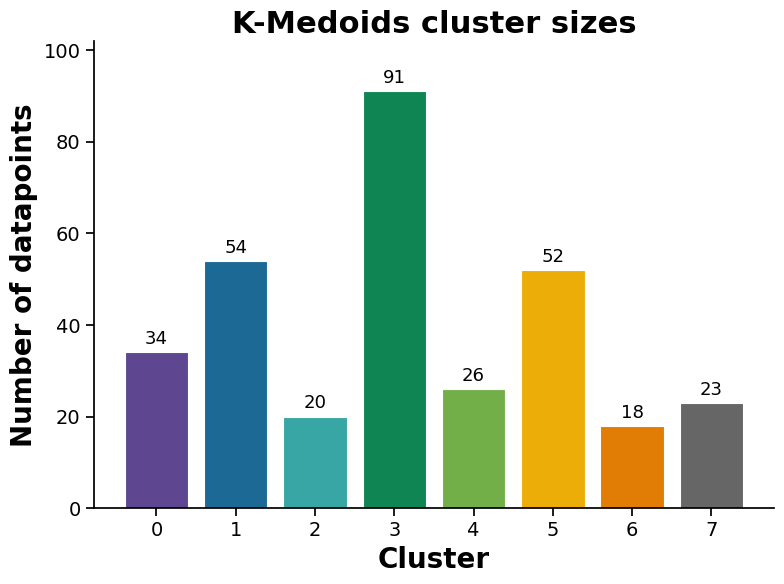

In [141]:
kmedoids_scores, kmedoids_labels, kmedoid_indices, kmedoids_tsne = get_clusters(
                  fp_vector=count_scaled_vector,
                  method='KMedoids',
                  n_clusters=8,
                  plotting=True,
                  get_label=True,
                  perplexity=30,
                  loc = 'upper center',
                  metric='euclidean'
                  )

kmedoids_cluster_sizes = plot_cluster_count(
    kmedoids_labels,
    title='K-Medoids cluster sizes',
)


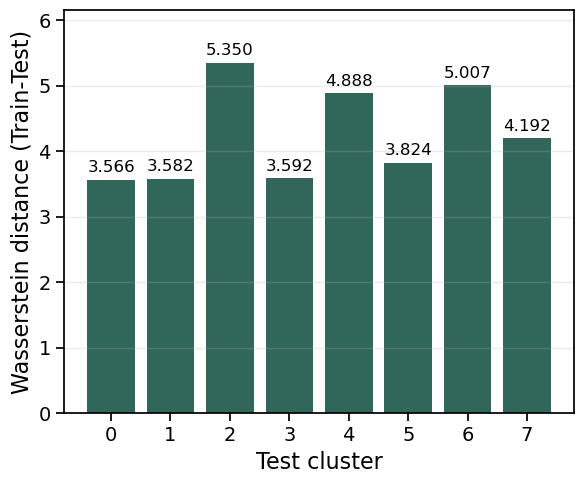

In [142]:
plot_cluster_wasserstein_distances(
    count_scaled_vector,
    kmedoids_labels,
    # title="",
    figsize=(6, 5)
)


### Clustering FPs